In [ ]:
from google.colab import drive
drive.mount("/content/drive")
!pip install -q openpyxl scikit-learn joblib
from pathlib import Path
from collections import Counter
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn


from sklearn.base import clone
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    brier_score_loss,
    log_loss,
    roc_curve,
    precision_recall_curve
)

RANDOM_STATE = 42


DATA_PATH = Path(
    "/content/drive/MyDrive/"
    "clinical_cad/data/"
    "extention of Z-Alizadeh sani dataset.xlsx"
)

SVM_RESULT_DIR = Path(
    "/content/drive/MyDrive/"
    "clinical_cad/results/svm"
)
SVM_FIGURE_DIR = (
    SVM_RESULT_DIR / "figures"
)
SVM_TABLE_DIR = (
    SVM_RESULT_DIR / "tables"
)
SVM_MODEL_DIR = (
    SVM_RESULT_DIR / "model"
)
SVM_REPORT_DIR = (
    SVM_RESULT_DIR / "final_report"
)

for directory in [
    SVM_RESULT_DIR,
    SVM_FIGURE_DIR,
    SVM_TABLE_DIR,
    SVM_MODEL_DIR,
    SVM_REPORT_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )



print("=" * 95)
print("[SVM Environment]")
print("=" * 95)

print(
    "scikit-learn version :",
    sklearn.__version__
)

print(
    "Random State         :",
    RANDOM_STATE
)

print(
    "Dataset Exists       :",
    DATA_PATH.exists()
)

print(
    "Dataset Path         :",
    DATA_PATH
)

print(
    "SVM Result Directory :",
    SVM_RESULT_DIR
)


assert DATA_PATH.exists(), (
    f"Dataset을 찾을 수 없습니다:\n{DATA_PATH}"
)


print()
print(
    "✅ STEP SVM-0 환경 설정 완료"
)

Mounted at /content/drive
[SVM Environment]
scikit-learn version : 1.6.1
Random State         : 42
Dataset Exists       : True
Dataset Path         : /content/drive/MyDrive/clinical_cad/data/extention of Z-Alizadeh sani dataset.xlsx
SVM Result Directory : /content/drive/MyDrive/clinical_cad/results/svm

✅ STEP SVM-0 환경 설정 완료


# 데이터 로드

In [ ]:
# 데이터 Sheet 로드

df = pd.read_excel(
    DATA_PATH,
    sheet_name="Sheet 1 - Table 1"
)

print()
print("=" * 95)
print("[2. Raw Dataset]")
print("=" * 95)

print(
    "Shape :",
    df.shape
)



# Target 생성
y = df["Cath"].map(
    {
        "CAD": 1,
        "Normal": 0
    }
)


assert y.isna().sum() == 0, (
    "Cath에 예상하지 못한 값이 존재합니다."
)



# Screening Input 생성
#
# 제외:LAD, LCX, RCA, Cath

X = df.drop(
    columns=[
        "LAD",
        "LCX",
        "RCA",
        "Cath"
    ]
).copy()



# Zero-variance feature 제거
assert X["Exertional CP"].nunique(
    dropna=False
) == 1, (
    "Exertional CP가 더 이상 zero-variance가 아닙니다. "
    "데이터 파일을 다시 확인하세요."
)


X_baseline = X.drop(
    columns=[
        "Exertional CP"
    ]
).copy()



# LR 실험과 동일한 데이터인지 검증
EXPECTED_N_PATIENTS = 303
EXPECTED_RAW_COLUMNS = 59
EXPECTED_CAD = 216
EXPECTED_NORMAL = 87
EXPECTED_SCREENING_FEATURES = 55
EXPECTED_FINAL_RAW_FEATURES = 54


assert df.shape == (
    EXPECTED_N_PATIENTS,
    EXPECTED_RAW_COLUMNS
), (
    f"원본 shape이 LR과 다릅니다: {df.shape}"
)
assert int(
    (y == 1).sum()
) == EXPECTED_CAD, (
    "CAD 환자 수가 LR과 다릅니다."
)
assert int(
    (y == 0).sum()
) == EXPECTED_NORMAL, (
    "Normal 환자 수가 LR과 다릅니다."
)
assert X.shape[1] == (
    EXPECTED_SCREENING_FEATURES
), (
    f"Leakage 제거 후 feature 수가 다릅니다: {X.shape[1]}"
)
assert X_baseline.shape[1] == (
    EXPECTED_FINAL_RAW_FEATURES
), (
    f"최종 raw feature 수가 다릅니다: {X_baseline.shape[1]}"
)


# Leakage 최종 확인
leakage_columns = [
    column
    for column in [
        "LAD",
        "LCX",
        "RCA",
        "Cath"
    ]
    if column in X_baseline.columns
]


assert len(
    leakage_columns
) == 0, (
    f"Leakage column이 남아 있습니다: {leakage_columns}"
)



# 결과 출력
print()
print("=" * 95)
print("[3. Target]")
print("=" * 95)

print(
    "Total  :",
    len(y)
)

print(
    "CAD    :",
    int(
        (y == 1).sum()
    )
)

print(
    "Normal :",
    int(
        (y == 0).sum()
    )
)

print(
    "CAD Prevalence :",
    f"{y.mean():.4f}",
    f"({y.mean() * 100:.2f}%)"
)


print()
print("=" * 95)
print("[4. Feature Set]")
print("=" * 95)

print(
    "After Leakage Removal :",
    X.shape
)

print(
    "Final SVM Raw Input   :",
    X_baseline.shape
)

print(
    "Removed Zero-Variance :",
    "Exertional CP"
)

print(
    "Remaining Leakage     :",
    leakage_columns
)



# Column 순서 일부 확인
print()
print("=" * 95)
print("[5. Raw Feature 확인]")
print("=" * 95)

print(
    "First 10 Features :",
    X_baseline.columns[:10].tolist()
)

print(
    "Last 10 Features  :",
    X_baseline.columns[-10:].tolist()
)


print()
print(
    "✅ STEP SVM-1 "
    "LR-Compatible Dataset Reconstruction 완료"
)

[1. Excel Sheet 확인]
Sheets : ['Sheet 1 - Table 1', 'Sheet1']

[2. Raw Dataset]
Shape : (303, 59)

[3. Target]
Total  : 303
CAD    : 216
Normal : 87
CAD Prevalence : 0.7129 (71.29%)

[4. Feature Set]
After Leakage Removal : (303, 55)
Final SVM Raw Input   : (303, 54)
Removed Zero-Variance : Exertional CP
Remaining Leakage     : []

[5. Raw Feature 확인]
First 10 Features : ['Age', 'Weight', 'Length', 'Sex', 'BMI', 'DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH']
Last 10 Features  : ['HB', 'K', 'Na', 'WBC', 'Lymph', 'Neut', 'PLT', 'EF-TTE', 'Region RWMA', 'VHD']

✅ STEP SVM-1 LR-Compatible Dataset Reconstruction 완료


# 전처리

In [ ]:
# LR과 동일한 feature grouping / encoding / scaling을 사용



# Feature Group 정의
continuous_features = [
    "Age",
    "Weight",
    "Length",
    "BMI",
    "BP",
    "PR",
    "FBS",
    "CR",
    "TG",
    "LDL",
    "HDL",
    "BUN",
    "ESR",
    "HB",
    "K",
    "Na",
    "WBC",
    "Lymph",
    "Neut",
    "PLT",
    "EF-TTE"
]


binary_numeric_features = [
    "DM",
    "HTN",
    "Current Smoker",
    "EX-Smoker",
    "FH",
    "Edema",
    "Typical Chest Pain",
    "Q Wave",
    "St Elevation",
    "St Depression",
    "Tinversion"
]


binary_yn_features = [
    "Obesity",
    "CRF",
    "CVA",
    "Airway disease",
    "Thyroid Disease",
    "CHF",
    "DLP",
    "Weak Peripheral Pulse",
    "Lung rales",
    "Systolic Murmur",
    "Diastolic Murmur",
    "Dyspnea",
    "Atypical",
    "Nonanginal",
    "LowTH Ang",
    "LVH",
    "Poor R Progression"
]


sex_feature = [
    "Sex"
]


nominal_features = [
    "BBB"
]


ordered_numeric_features = [
    "Function Class",
    "Region RWMA"
]


ordered_string_features = [
    "VHD"
]



# Feature Group Coverage 검증
all_defined_features = (
    continuous_features
    + binary_numeric_features
    + binary_yn_features
    + sex_feature
    + nominal_features
    + ordered_numeric_features
    + ordered_string_features
)


missing_from_definition = sorted(
    set(X_baseline.columns)
    -
    set(all_defined_features)
)


extra_in_definition = sorted(
    set(all_defined_features)
    -
    set(X_baseline.columns)
)


duplicate_features = [
    feature
    for feature, count
    in Counter(
        all_defined_features
    ).items()
    if count > 1
]


print("=" * 95)
print("[1. Feature Group Validation]")
print("=" * 95)

print(
    "X_baseline Features :",
    X_baseline.shape[1]
)

print(
    "Defined Features    :",
    len(all_defined_features)
)

print(
    "Missing Definition  :",
    missing_from_definition
)

print(
    "Extra Definition    :",
    extra_in_definition
)

print(
    "Duplicate Features  :",
    duplicate_features
)


assert len(
    missing_from_definition
) == 0, (
    f"정의되지 않은 feature가 있습니다: {missing_from_definition}"
)

assert len(
    extra_in_definition
) == 0, (
    f"X_baseline에 없는 feature가 정의되어 있습니다: {extra_in_definition}"
)

assert len(
    duplicate_features
) == 0, (
    f"중복 정의 feature가 있습니다: {duplicate_features}"
)



# 각 Feature Group 전처리 정의
continuous_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)

binary_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        )
    ]
)


binary_yn_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OrdinalEncoder(
                categories=[
                    ["N", "Y"]
                    for _ in binary_yn_features
                ],

                handle_unknown="error"
            )
        )
    ]
)


sex_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OrdinalEncoder(
                categories=[
                    [
                        "Fmale",
                        "Male"
                    ]
                ],

                handle_unknown="error"
            )
        )
    ]
)

bbb_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                categories=[
                    [
                        "N",
                        "LBBB",
                        "RBBB"
                    ]
                ],

                drop="first",

                handle_unknown="error",

                sparse_output=False
            )
        )
    ]
)


ordered_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)


vhd_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OrdinalEncoder(
                categories=[
                    [
                        "N",
                        "mild",
                        "Moderate",
                        "Severe"
                    ]
                ],

                handle_unknown="error"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)



# ColumnTransformer 결합
preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous",
            continuous_transformer,
            continuous_features
        ),

        (
            "binary_numeric",
            binary_numeric_transformer,
            binary_numeric_features
        ),

        (
            "binary_yn",
            binary_yn_transformer,
            binary_yn_features
        ),

        (
            "sex",
            sex_transformer,
            sex_feature
        ),

        (
            "bbb",
            bbb_transformer,
            nominal_features
        ),

        (
            "ordered_numeric",
            ordered_numeric_transformer,
            ordered_numeric_features
        ),

        (
            "vhd",
            vhd_transformer,
            ordered_string_features
        )
    ],

    remainder="drop",

    verbose_feature_names_out=False
)


# 구조 검증용 임시 Fit
preprocessor_check = clone(
    preprocessor
)

X_transformed_check = (
    preprocessor_check.fit_transform(
        X_baseline
    )
)


transformed_feature_names = (
    preprocessor_check
    .get_feature_names_out()
)


# 최종 Dimension 검증
EXPECTED_RAW_FEATURES = 54
EXPECTED_TRANSFORMED_FEATURES = 55


assert X_baseline.shape[1] == (
    EXPECTED_RAW_FEATURES
)


assert X_transformed_check.shape == (
    303,
    EXPECTED_TRANSFORMED_FEATURES
), (
    "LR과 transformed feature dimension이 다릅니다. "
    f"현재 shape: {X_transformed_check.shape}"
)


assert len(
    transformed_feature_names
) == EXPECTED_TRANSFORMED_FEATURES



#  결과 출력
print()
print("=" * 95)
print("[2. Preprocessing Dimension Check]")
print("=" * 95)

print(
    "Raw Input Shape         :",
    X_baseline.shape
)

print(
    "Transformed Input Shape :",
    X_transformed_check.shape
)

print(
    "Raw Feature Count       :",
    X_baseline.shape[1]
)

print(
    "Transformed Count       :",
    len(transformed_feature_names)
)


print()
print("=" * 95)
print("[3. Feature Group Count]")
print("=" * 95)

print(
    "Continuous      :",
    len(continuous_features)
)

print(
    "Binary Numeric  :",
    len(binary_numeric_features)
)

print(
    "Binary Y/N      :",
    len(binary_yn_features)
)

print(
    "Sex             :",
    len(sex_feature)
)

print(
    "BBB Raw         :",
    len(nominal_features),
    "→ Encoded 2"
)

print(
    "Ordered Numeric :",
    len(ordered_numeric_features)
)

print(
    "VHD             :",
    len(ordered_string_features)
)


print()
print("=" * 95)
print("[4. Transformed Feature Names]")
print("=" * 95)

for i, feature in enumerate(
    transformed_feature_names,
    start=1
):

    print(
        f"{i:02d}. {feature}"
    )


print()
print(
    "✅ STEP SVM-2 "
    "LR-Compatible Preprocessing Reconstruction 완료"
)

[1. Feature Group Validation]
X_baseline Features : 54
Defined Features    : 54
Missing Definition  : []
Extra Definition    : []
Duplicate Features  : []

[2. Preprocessing Dimension Check]
Raw Input Shape         : (303, 54)
Transformed Input Shape : (303, 55)
Raw Feature Count       : 54
Transformed Count       : 55

[3. Feature Group Count]
Continuous      : 21
Binary Numeric  : 11
Binary Y/N      : 17
Sex             : 1
BBB Raw         : 1 → Encoded 2
Ordered Numeric : 2
VHD             : 1

[4. Transformed Feature Names]
01. Age
02. Weight
03. Length
04. BMI
05. BP
06. PR
07. FBS
08. CR
09. TG
10. LDL
11. HDL
12. BUN
13. ESR
14. HB
15. K
16. Na
17. WBC
18. Lymph
19. Neut
20. PLT
21. EF-TTE
22. DM
23. HTN
24. Current Smoker
25. EX-Smoker
26. FH
27. Edema
28. Typical Chest Pain
29. Q Wave
30. St Elevation
31. St Depression
32. Tinversion
33. Obesity
34. CRF
35. CVA
36. Airway disease
37. Thyroid Disease
38. CHF
39. DLP
40. Weak Peripheral Pulse
41. Lung rales
42. Systolic Murmur
4

In [ ]:
# Linear SVM vs RBF SVM Baseline
# Stratified 10-Fold Cross-Validation
# 동일 조건에서 비교

from sklearn.metrics import (
    make_scorer,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict
)

from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.base import clone

import numpy as np
import pandas as pd



# Baseline CV
svm_baseline_cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)



# Scoring 정의
specificity_scorer = make_scorer(
    recall_score,
    pos_label=0
)


precision_scorer = make_scorer(
    precision_score,
    pos_label=1,
    zero_division=0
)


f1_scorer = make_scorer(
    f1_score,
    pos_label=1,
    zero_division=0
)


svm_scoring = {
    "AUROC":
        "roc_auc",

    "AUPRC":
        "average_precision",

    "Accuracy":
        "accuracy",

    "Precision":
        precision_scorer,

    "Sensitivity":
        "recall",

    "Specificity":
        specificity_scorer,

    "F1":
        f1_scorer
}



# Baseline SVM 후보
svm_baseline_models = {

    "Linear SVM":

        Pipeline(
            steps=[
                (
                    "preprocessor",
                    clone(preprocessor)
                ),

                (
                    "model",
                    SVC(
                        kernel="linear",
                        C=1.0,
                        class_weight=None,
                        cache_size=1000
                    )
                )
            ]
        ),


    "RBF SVM":

        Pipeline(
            steps=[
                (
                    "preprocessor",
                    clone(preprocessor)
                ),

                (
                    "model",
                    SVC(
                        kernel="rbf",
                        C=1.0,
                        gamma="scale",
                        class_weight=None,
                        cache_size=1000
                    )
                )
            ]
        )
}



# 모델별 10-Fold CV 실행
baseline_summary_rows = []

baseline_oof_rows = []

baseline_confusion_tables = {}

baseline_fold_tables = {}


for model_name, model_pipeline in svm_baseline_models.items():

    print()
    print("=" * 100)
    print(f"[{model_name} - 10-Fold CV 실행]")
    print("=" * 100)



    # Fold별 Cross-Validation
    cv_result = cross_validate(
        estimator=model_pipeline,
        X=X_baseline,
        y=y,
        cv=svm_baseline_cv,
        scoring=svm_scoring,
        return_train_score=True,
        n_jobs=-1
    )



    # Fold별 결과 DataFrame
    fold_df = pd.DataFrame({
        "Fold":
            np.arange(
                1,
                11
            ),

        "AUROC":
            cv_result[
                "test_AUROC"
            ],

        "AUPRC":
            cv_result[
                "test_AUPRC"
            ],

        "Accuracy":
            cv_result[
                "test_Accuracy"
            ],

        "Precision":
            cv_result[
                "test_Precision"
            ],

        "Sensitivity":
            cv_result[
                "test_Sensitivity"
            ],

        "Specificity":
            cv_result[
                "test_Specificity"
            ],

        "F1":
            cv_result[
                "test_F1"
            ],

        "Train AUROC":
            cv_result[
                "train_AUROC"
            ]
    })


    baseline_fold_tables[
        model_name
    ] = fold_df



    # OOF Decision Score 생성
    oof_score = cross_val_predict(
        estimator=model_pipeline,
        X=X_baseline,
        y=y,
        cv=svm_baseline_cv,
        method="decision_function",
        n_jobs=-1
    )


    # SVM 기본 decision boundary
    oof_pred = (
        oof_score >= 0
    ).astype(int)



    # Pooled OOF Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(
        y,
        oof_pred,
        labels=[0, 1]
    ).ravel()


    sensitivity = (
        tp /
        (tp + fn)
    )

    specificity = (
        tn /
        (tn + fp)
    )
    precision = (
        tp /
        (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )
    npv = (
        tn /
        (tn + fn)
        if (tn + fn) > 0
        else np.nan
    )
    pooled_auroc = roc_auc_score(
        y,
        oof_score
    )
    pooled_auprc = average_precision_score(
        y,
        oof_score
    )

    pooled_accuracy = accuracy_score(
        y,
        oof_pred
    )

    pooled_f1 = f1_score(
        y,
        oof_pred,
        zero_division=0
    )



    # Fold Mean ± SD 및 Train-Val Gap
    mean_test_auroc = (
        fold_df["AUROC"].mean()
    )

    sd_test_auroc = (
        fold_df["AUROC"].std(
            ddof=1
        )
    )

    mean_train_auroc = (
        fold_df["Train AUROC"].mean()
    )

    train_val_gap = (
        mean_train_auroc
        -
        mean_test_auroc
    )

    baseline_summary_rows.append({
        "Model":
            model_name,

        "AUROC Mean":
            mean_test_auroc,

        "AUROC SD":
            sd_test_auroc,

        "AUPRC Mean":
            fold_df[
                "AUPRC"
            ].mean(),

        "AUPRC SD":
            fold_df[
                "AUPRC"
            ].std(
                ddof=1
            ),

        "Accuracy Mean":
            fold_df[
                "Accuracy"
            ].mean(),

        "Sensitivity Mean":
            fold_df[
                "Sensitivity"
            ].mean(),

        "Specificity Mean":
            fold_df[
                "Specificity"
            ].mean(),

        "F1 Mean":
            fold_df[
                "F1"
            ].mean(),

        "Train AUROC Mean":
            mean_train_auroc,

        "Train-Val AUROC Gap":
            train_val_gap,

        "Pooled OOF AUROC":
            pooled_auroc,

        "Pooled OOF AUPRC":
            pooled_auprc,

        "Pooled Sensitivity":
            sensitivity,

        "Pooled Specificity":
            specificity,

        "Pooled Precision":
            precision,

        "Pooled NPV":
            npv,

        "Pooled Accuracy":
            pooled_accuracy,

        "Pooled F1":
            pooled_f1,

        "TN":
            tn,

        "FP":
            fp,

        "FN":
            fn,

        "TP":
            tp
    })


    baseline_confusion_tables[
        model_name
    ] = pd.DataFrame(
        [
            [tn, fp],
            [fn, tp]
        ],
        index=[
            "Actual Normal",
            "Actual CAD"
        ],
        columns=[
            "Predicted Normal",
            "Predicted CAD"
        ]
    )


    baseline_oof_rows.append(
        pd.DataFrame({
            "Patient_Index":
                X_baseline.index,

            "True_Label":
                np.asarray(y),

            "Model":
                model_name,

            "Decision_Score":
                oof_score,

            "Prediction_Default_Boundary":
                oof_pred
        })
    )



# Baseline Summary
svm_baseline_summary = pd.DataFrame(
    baseline_summary_rows
)


# AUROC 기준으로 정렬
svm_baseline_summary = (
    svm_baseline_summary
    .sort_values(
        "Pooled OOF AUROC",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print()
print("=" * 100)
print("[1. Linear vs RBF SVM - Baseline Summary]")
print("=" * 100)


display(
    svm_baseline_summary.round(4)
)



# Fold Mean ± SD를 보기 좋은 형태로 정리
baseline_compact_rows = []


for _, row in svm_baseline_summary.iterrows():

    baseline_compact_rows.append({

        "Model":
            row["Model"],

        "AUROC":
            (
                f"{row['AUROC Mean']:.4f} "
                f"± {row['AUROC SD']:.4f}"
            ),

        "AUPRC":
            (
                f"{row['AUPRC Mean']:.4f} "
                f"± {row['AUPRC SD']:.4f}"
            ),

        "Accuracy":
            f"{row['Accuracy Mean']:.4f}",

        "Sensitivity":
            f"{row['Sensitivity Mean']:.4f}",

        "Specificity":
            f"{row['Specificity Mean']:.4f}",

        "F1":
            f"{row['F1 Mean']:.4f}",

        "Train AUROC":
            f"{row['Train AUROC Mean']:.4f}",

        "Train-Val Gap":
            f"{row['Train-Val AUROC Gap']:.4f}"
    })


svm_baseline_compact = pd.DataFrame(
    baseline_compact_rows
)


print()
print("=" * 100)
print("[2. Fold Mean ± SD]")
print("=" * 100)

display(
    svm_baseline_compact
)



# Pooled OOF 성능
pooled_columns = [
    "Model",
    "Pooled OOF AUROC",
    "Pooled OOF AUPRC",
    "Pooled Accuracy",
    "Pooled Precision",
    "Pooled Sensitivity",
    "Pooled Specificity",
    "Pooled NPV",
    "Pooled F1",
    "TN",
    "FP",
    "FN",
    "TP"
]


print()
print("=" * 100)
print("[3. Pooled OOF Baseline Performance]")
print("=" * 100)


display(
    svm_baseline_summary[
        pooled_columns
    ].round(4)
)



# Confusion Matrix 출력
for model_name in [
    "Linear SVM",
    "RBF SVM"
]:

    print()
    print("=" * 100)
    print(
        f"[4. {model_name} - "
        "Pooled OOF Confusion Matrix]"
    )
    print("=" * 100)

    display(
        baseline_confusion_tables[
            model_name
        ]
    )



# 결과 저장
baseline_summary_path = (
    SVM_TABLE_DIR /
    "01_svm_linear_vs_rbf_baseline_summary.csv"
)


svm_baseline_summary.to_csv(
    baseline_summary_path,
    index=False
)


# 환자별 OOF score
svm_baseline_oof_df = pd.concat(
    baseline_oof_rows,
    ignore_index=True
)


baseline_oof_path = (
    SVM_TABLE_DIR /
    "02_svm_linear_vs_rbf_baseline_oof_scores.csv"
)


svm_baseline_oof_df.to_csv(
    baseline_oof_path,
    index=False
)


# Fold별 상세 결과도 각각 저장
for model_name, fold_df in (
    baseline_fold_tables.items()
):

    safe_name = (
        model_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    fold_path = (
        SVM_TABLE_DIR /
        f"03_{safe_name}_baseline_fold_metrics.csv"
    )

    fold_df.to_csv(
        fold_path,
        index=False
    )


print()
print("=" * 100)
print("[저장 완료]")
print("=" * 100)

print(
    "Baseline Summary :",
    baseline_summary_path
)

print(
    "OOF Scores       :",
    baseline_oof_path
)


print()
print(
    "✅ STEP SVM-3 "
    "Linear vs RBF Baseline Comparison 완료"
)

print()

print(
    "※ 현재 결과는 untuned baseline입니다."
)

print(
    "※ AUROC/AUPRC는 decision_function 기반입니다."
)

print(
    "※ Sensitivity/Specificity는 기본 decision boundary=0 기준입니다."
)

print(
    "※ 최종 SVM 성능으로 보고하지 않습니다."
)


[Linear SVM - 10-Fold CV 실행]

[RBF SVM - 10-Fold CV 실행]

[1. Linear vs RBF SVM - Baseline Summary]


,Model,AUROC Mean,AUROC SD,AUPRC Mean,AUPRC SD,Accuracy Mean,Sensitivity Mean,Specificity Mean,F1 Mean,Train AUROC Mean,...,Pooled Sensitivity,Pooled Specificity,Pooled Precision,Pooled NPV,Pooled Accuracy,Pooled F1,TN,FP,FN,TP
0,RBF SVM,0.9118,0.0693,0.9557,0.0413,0.8576,0.9439,0.6417,0.9044,0.9862,...,0.9444,0.6437,0.8681,0.8235,0.8581,0.9047,56,31,12,204
1,Linear SVM,0.9105,0.0504,0.9654,0.0196,0.8513,0.8929,0.7444,0.8947,0.9744,...,0.8935,0.7471,0.8977,0.7386,0.8515,0.8956,65,22,23,193



[2. Fold Mean ± SD]


,Model,AUROC,AUPRC,Accuracy,Sensitivity,Specificity,F1,Train AUROC,Train-Val Gap
0,RBF SVM,0.9118 ± 0.0693,0.9557 ± 0.0413,0.8576,0.9439,0.6417,0.9044,0.9862,0.0744
1,Linear SVM,0.9105 ± 0.0504,0.9654 ± 0.0196,0.8513,0.8929,0.7444,0.8947,0.9744,0.0639



[3. Pooled OOF Baseline Performance]


...


[4. Linear SVM - Pooled OOF Confusion Matrix]


,Predicted Normal,Predicted CAD
Actual Normal,65,22
Actual CAD,23,193



[4. RBF SVM - Pooled OOF Confusion Matrix]


,Predicted Normal,Predicted CAD
Actual Normal,56,31
Actual CAD,12,204



[저장 완료]
Baseline Summary : /content/drive/MyDrive/clinical_cad/results/svm/tables/01_svm_linear_vs_rbf_baseline_summary.csv
OOF Scores       : /content/drive/MyDrive/clinical_cad/results/svm/tables/02_svm_linear_vs_rbf_baseline_oof_scores.csv

✅ STEP SVM-3 Linear vs RBF Baseline Comparison 완료

※ 현재 결과는 untuned baseline입니다.
※ AUROC/AUPRC는 decision_function 기반입니다.
※ Sensitivity/Specificity는 기본 decision boundary=0 기준입니다.
※ 최종 SVM 성능으로 보고하지 않습니다.


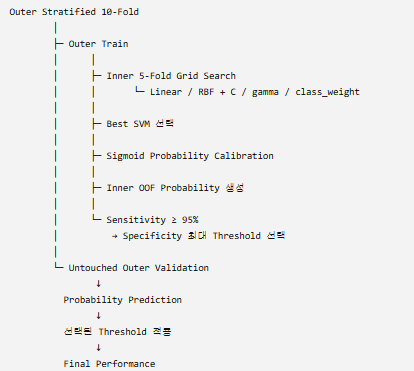

# Final Nested CV

In [ ]:
# -----------------------------------------------------------------------------
# 1. Library
# -----------------------------------------------------------------------------

import numpy as np
import pandas as pd

from collections import Counter

from sklearn.base import clone

from sklearn.pipeline import Pipeline

from sklearn.svm import SVC

from sklearn.calibration import (
    CalibratedClassifierCV
)

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    cross_val_predict
)

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    brier_score_loss,
    log_loss
)


# =============================================================================
# 2. Screening Threshold Target
# =============================================================================
#
# LR과 동일한 정책
#
# Sensitivity >= 95%
#
# 를 우선 만족한 뒤
# 그 범위에서 Specificity 최대화.
# =============================================================================

SVM_SENSITIVITY_TARGET = 0.95


# =============================================================================
# 3. Outer CV
# =============================================================================

svm_outer_cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)


# =============================================================================
# 4. Base SVM Pipeline
# =============================================================================
svm_base_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),

        (
            "model",
            SVC(
                cache_size=1000,
                probability=False
            )
        )
    ]
)


# =============================================================================
# 5. Hyperparameter Search Space
# =============================================================================

svm_param_grid = [

    # -------------------------------------------------------------------------
    # Linear SVM
    # -------------------------------------------------------------------------
    {
        "model__kernel": [
            "linear"
        ],

        "model__C": [
            0.01,
            0.1,
            1,
            10,
            100
        ],

        "model__class_weight": [
            None,
            "balanced"
        ]
    },


    # -------------------------------------------------------------------------
    # RBF SVM
    # -------------------------------------------------------------------------
    {
        "model__kernel": [
            "rbf"
        ],

        "model__C": [
            0.1,
            1,
            10,
            100
        ],

        "model__gamma": [
            "scale",
            0.01,
            0.1,
            1
        ],

        "model__class_weight": [
            None,
            "balanced"
        ]
    }
]


# =============================================================================
# 6. Threshold Selection Function
# =============================================================================

def select_screening_threshold(
    y_true,
    y_proba,
    sensitivity_target=0.95
):

    y_true = np.asarray(
        y_true,
        dtype=int
    )

    y_proba = np.asarray(
        y_proba,
        dtype=float
    )


    candidate_thresholds = np.sort(
        np.unique(
            y_proba
        )
    )


    rows = []


    for threshold in candidate_thresholds:

        y_pred = (
            y_proba >= threshold
        ).astype(int)


        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[
                0,
                1
            ]
        ).ravel()


        sensitivity = (
            tp / (tp + fn)
        )


        specificity = (
            tn / (tn + fp)
        )


        rows.append({
            "Threshold":
                threshold,

            "Sensitivity":
                sensitivity,

            "Specificity":
                specificity,

            "TN":
                tn,

            "FP":
                fp,

            "FN":
                fn,

            "TP":
                tp
        })


    threshold_df = pd.DataFrame(
        rows
    )


    eligible_df = (
        threshold_df[
            threshold_df[
                "Sensitivity"
            ] >= sensitivity_target
        ]
        .copy()
    )


    if len(
        eligible_df
    ) == 0:

        raise ValueError(
            "Sensitivity target을 만족하는 "
            "threshold를 찾지 못했습니다."
        )


    # -------------------------------------------------------------------------
    # 우선순위
    # 1. Specificity 최대
    # 2. 동일 specificity이면 threshold 높은 값
    # -------------------------------------------------------------------------

    eligible_df = (
        eligible_df
        .sort_values(
            by=[
                "Specificity",
                "Threshold"
            ],
            ascending=[
                False,
                False
            ]
        )
        .reset_index(
            drop=True
        )
    )


    selected = (
        eligible_df.iloc[0]
    )


    return (
        float(
            selected[
                "Threshold"
            ]
        ),
        selected,
        threshold_df
    )


# =============================================================================
# 7. Final Nested OOF 저장 배열
# =============================================================================

n_samples = len(
    X_baseline
)


svm_nested_oof_proba = np.full(
    n_samples,
    np.nan
)


svm_nested_oof_pred = np.full(
    n_samples,
    -1,
    dtype=int
)


fold_result_rows = []

parameter_rows = []


# =============================================================================
# 8. OUTER LOOP
# =============================================================================

for outer_fold, (
    train_idx,
    valid_idx
) in enumerate(
    svm_outer_cv.split(
        X_baseline,
        y
    ),
    start=1
):

    print()
    print("=" * 110)

    print(
        f"[Outer Fold {outer_fold}/10]"
    )

    print("=" * 110)


    # -------------------------------------------------------------------------
    # 8-1. Outer Train / Validation
    # -------------------------------------------------------------------------

    X_outer_train = (
        X_baseline.iloc[
            train_idx
        ]
    )

    X_outer_valid = (
        X_baseline.iloc[
            valid_idx
        ]
    )


    y_outer_train = (
        y.iloc[
            train_idx
        ]
    )

    y_outer_valid = (
        y.iloc[
            valid_idx
        ]
    )


    # =========================================================================
    # 9. Inner Grid Search
    # =========================================================================

    svm_inner_cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=(
            RANDOM_STATE
            +
            outer_fold
        )
    )


    svm_grid = GridSearchCV(
        estimator=clone(
            svm_base_pipeline
        ),

        param_grid=svm_param_grid,

        scoring="roc_auc",

        cv=svm_inner_cv,

        refit=True,

        n_jobs=-1
    )


    svm_grid.fit(
        X_outer_train,
        y_outer_train
    )


    best_params = (
        svm_grid.best_params_
    )


    best_inner_auroc = (
        svm_grid.best_score_
    )


    best_kernel = (
        best_params[
            "model__kernel"
        ]
    )


    best_C = (
        best_params[
            "model__C"
        ]
    )


    best_class_weight = (
        best_params[
            "model__class_weight"
        ]
    )


    best_gamma = (
        best_params.get(
            "model__gamma",
            None
        )
    )


    print(
        "Best Kernel       :",
        best_kernel
    )

    print(
        "Best C            :",
        best_C
    )

    print(
        "Best Gamma        :",
        best_gamma
    )

    print(
        "Best Class Weight :",
        best_class_weight
    )

    print(
        "Inner AUROC       :",
        round(
            best_inner_auroc,
            4
        )
    )


    # =========================================================================
    # 10. 선택된 SVM Pipeline 생성
    # =========================================================================

    selected_svm = clone(
        svm_base_pipeline
    )


    selected_svm.set_params(
        **best_params
    )


    # =========================================================================
    # 11. Probability Calibration
    # =========================================================================

    calibration_cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=(
            RANDOM_STATE
            +
            1000
            +
            outer_fold
        )
    )


    calibrated_svm = CalibratedClassifierCV(
        estimator=selected_svm,
        method="sigmoid",
        cv=calibration_cv,
        ensemble=True,
        n_jobs=1
    )


    # =========================================================================
    # 12. Threshold Selection용 Inner OOF Probability
    # =========================================================================

    threshold_inner_cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=(
            RANDOM_STATE
            +
            2000
            +
            outer_fold
        )
    )


    inner_oof_proba = cross_val_predict(
        estimator=calibrated_svm,

        X=X_outer_train,

        y=y_outer_train,

        cv=threshold_inner_cv,

        method="predict_proba",

        n_jobs=-1
    )[:, 1]


    # =========================================================================
    # 13. Inner Threshold Optimization
    # =========================================================================

    (
        selected_threshold,
        selected_threshold_row,
        _
    ) = select_screening_threshold(

        y_true=y_outer_train,

        y_proba=inner_oof_proba,

        sensitivity_target=
            SVM_SENSITIVITY_TARGET
    )


    print(
        "Selected Threshold:",
        round(
            selected_threshold,
            4
        )
    )

    print(
        "Inner Sensitivity :",
        round(
            selected_threshold_row[
                "Sensitivity"
            ],
            4
        )
    )

    print(
        "Inner Specificity :",
        round(
            selected_threshold_row[
                "Specificity"
            ],
            4
        )
    )


    # =========================================================================
    # 14. Outer Train 전체로 calibrated SVM Fit
    # =========================================================================

    calibrated_svm.fit(
        X_outer_train,
        y_outer_train
    )


    # =========================================================================
    # 15. Untouched Outer Validation Probability
    # =========================================================================

    outer_proba = (
        calibrated_svm
        .predict_proba(
            X_outer_valid
        )[:, 1]
    )


    outer_pred = (
        outer_proba
        >=
        selected_threshold
    ).astype(int)


    # OOF 저장
    svm_nested_oof_proba[
        valid_idx
    ] = outer_proba


    svm_nested_oof_pred[
        valid_idx
    ] = outer_pred


    # =========================================================================
    # 16. Outer Validation Metrics
    # =========================================================================

    tn, fp, fn, tp = confusion_matrix(
        y_outer_valid,
        outer_pred,
        labels=[
            0,
            1
        ]
    ).ravel()


    outer_auroc = roc_auc_score(
        y_outer_valid,
        outer_proba
    )


    outer_auprc = average_precision_score(
        y_outer_valid,
        outer_proba
    )


    outer_accuracy = accuracy_score(
        y_outer_valid,
        outer_pred
    )


    outer_precision = precision_score(
        y_outer_valid,
        outer_pred,
        zero_division=0
    )


    outer_sensitivity = recall_score(
        y_outer_valid,
        outer_pred,
        pos_label=1
    )


    outer_specificity = (
        tn /
        (tn + fp)
    )


    outer_npv = (
        tn /
        (tn + fn)
        if (tn + fn) > 0
        else np.nan
    )


    outer_f1 = f1_score(
        y_outer_valid,
        outer_pred,
        zero_division=0
    )


    print(
        "Outer AUROC       :",
        round(
            outer_auroc,
            4
        )
    )

    print(
        "Outer Sensitivity :",
        round(
            outer_sensitivity,
            4
        )
    )

    print(
        "Outer Specificity :",
        round(
            outer_specificity,
            4
        )
    )


    fold_result_rows.append({

        "Outer Fold":
            outer_fold,

        "Kernel":
            best_kernel,

        "C":
            best_C,

        "Gamma":
            best_gamma,

        "Class Weight":
            best_class_weight,

        "Inner Best AUROC":
            best_inner_auroc,

        "Threshold":
            selected_threshold,

        "Inner Sensitivity":
            selected_threshold_row[
                "Sensitivity"
            ],

        "Inner Specificity":
            selected_threshold_row[
                "Specificity"
            ],

        "Outer AUROC":
            outer_auroc,

        "Outer AUPRC":
            outer_auprc,

        "Outer Accuracy":
            outer_accuracy,

        "Outer Precision":
            outer_precision,

        "Outer Sensitivity":
            outer_sensitivity,

        "Outer Specificity":
            outer_specificity,

        "Outer NPV":
            outer_npv,

        "Outer F1":
            outer_f1,

        "TN":
            tn,

        "FP":
            fp,

        "FN":
            fn,

        "TP":
            tp
    })


# =============================================================================
# 17. OOF 완성 검증
# =============================================================================

assert np.isnan(
    svm_nested_oof_proba
).sum() == 0, (
    "Nested OOF probability에 NaN이 있습니다."
)


assert np.all(
    svm_nested_oof_pred >= 0
), (
    "Nested OOF prediction이 완성되지 않았습니다."
)


# =============================================================================
# 18. Fold Results
# =============================================================================

svm_nested_fold_results = pd.DataFrame(
    fold_result_rows
)


print()
print("=" * 110)
print("[1. Final Nested CV - Fold Results]")
print("=" * 110)

display(
    svm_nested_fold_results.round(4)
)


# =============================================================================
# 19. Fold Mean ± SD
# =============================================================================

metric_columns = [
    "Outer AUROC",
    "Outer AUPRC",
    "Outer Accuracy",
    "Outer Precision",
    "Outer Sensitivity",
    "Outer Specificity",
    "Outer NPV",
    "Outer F1"
]


fold_summary_rows = []


for metric in metric_columns:

    fold_summary_rows.append({

        "Metric":
            metric.replace(
                "Outer ",
                ""
            ),

        "Mean":
            svm_nested_fold_results[
                metric
            ].mean(),

        "SD":
            svm_nested_fold_results[
                metric
            ].std(
                ddof=1
            )
    })


svm_nested_fold_summary = pd.DataFrame(
    fold_summary_rows
)


print()
print("=" * 110)
print("[2. Final Nested CV - Fold Mean ± SD]")
print("=" * 110)

display(
    svm_nested_fold_summary.round(4)
)


# =============================================================================
# 20. Pooled Nested Outer OOF Performance
# =============================================================================

pooled_tn, pooled_fp, pooled_fn, pooled_tp = (
    confusion_matrix(
        y,
        svm_nested_oof_pred,
        labels=[
            0,
            1
        ]
    ).ravel()
)


pooled_auroc = roc_auc_score(
    y,
    svm_nested_oof_proba
)


pooled_auprc = average_precision_score(
    y,
    svm_nested_oof_proba
)


pooled_accuracy = accuracy_score(
    y,
    svm_nested_oof_pred
)


pooled_precision = precision_score(
    y,
    svm_nested_oof_pred,
    zero_division=0
)


pooled_sensitivity = recall_score(
    y,
    svm_nested_oof_pred
)


pooled_specificity = (
    pooled_tn /
    (
        pooled_tn
        +
        pooled_fp
    )
)


pooled_npv = (
    pooled_tn /
    (
        pooled_tn
        +
        pooled_fn
    )
)


pooled_f1 = f1_score(
    y,
    svm_nested_oof_pred,
    zero_division=0
)


pooled_brier = brier_score_loss(
    y,
    svm_nested_oof_proba
)


pooled_logloss = log_loss(
    y,
    svm_nested_oof_proba
)


svm_nested_pooled_summary = pd.DataFrame(
    [
        {
            "AUROC":
                pooled_auroc,

            "AUPRC":
                pooled_auprc,

            "Accuracy":
                pooled_accuracy,

            "Precision":
                pooled_precision,

            "Sensitivity":
                pooled_sensitivity,

            "Specificity":
                pooled_specificity,

            "NPV":
                pooled_npv,

            "F1":
                pooled_f1,

            "Brier Score":
                pooled_brier,

            "Log Loss":
                pooled_logloss,

            "TN":
                pooled_tn,

            "FP":
                pooled_fp,

            "FN":
                pooled_fn,

            "TP":
                pooled_tp
        }
    ]
)


print()
print("=" * 110)
print("[3. Pooled Nested Outer OOF Performance]")
print("=" * 110)

display(
    svm_nested_pooled_summary.round(4)
)


# =============================================================================
# 21. Kernel / Parameter 선택 빈도
# =============================================================================

print()
print("=" * 110)
print("[4. Kernel Selection Frequency]")
print("=" * 110)

print(
    svm_nested_fold_results[
        "Kernel"
    ].value_counts()
)


print()
print("=" * 110)
print("[5. Selected Hyperparameters by Fold]")
print("=" * 110)


parameter_display_columns = [
    "Outer Fold",
    "Kernel",
    "C",
    "Gamma",
    "Class Weight",
    "Inner Best AUROC",
    "Threshold",
    "Inner Sensitivity",
    "Inner Specificity"
]


display(
    svm_nested_fold_results[
        parameter_display_columns
    ].round(4)
)


# =============================================================================
# 22. Threshold Distribution
# =============================================================================

threshold_values = (
    svm_nested_fold_results[
        "Threshold"
    ]
)


svm_threshold_summary = pd.DataFrame(
    [
        {
            "Mean":
                threshold_values.mean(),

            "Median":
                threshold_values.median(),

            "SD":
                threshold_values.std(
                    ddof=1
                ),

            "Min":
                threshold_values.min(),

            "Max":
                threshold_values.max()
        }
    ]
)


print()
print("=" * 110)
print("[6. Nested Threshold Distribution]")
print("=" * 110)

display(
    svm_threshold_summary.round(4)
)


# =============================================================================
# 23. OOF Patient-level Table
# =============================================================================

svm_nested_oof_df = pd.DataFrame({

    "Patient_Index":
        X_baseline.index,

    "True_Label":
        np.asarray(y),

    "Nested_OOF_Probability":
        svm_nested_oof_proba,

    "Nested_OOF_Prediction":
        svm_nested_oof_pred
})


# =============================================================================
# 24. 저장
# =============================================================================

fold_result_path = (
    SVM_TABLE_DIR /
    "04_svm_final_nested_fold_results.csv"
)


fold_summary_path = (
    SVM_TABLE_DIR /
    "05_svm_final_nested_fold_summary.csv"
)


pooled_summary_path = (
    SVM_TABLE_DIR /
    "06_svm_final_nested_pooled_summary.csv"
)


oof_path = (
    SVM_TABLE_DIR /
    "07_svm_final_nested_oof_predictions.csv"
)


threshold_summary_path = (
    SVM_TABLE_DIR /
    "08_svm_final_nested_threshold_summary.csv"
)


svm_nested_fold_results.to_csv(
    fold_result_path,
    index=False
)


svm_nested_fold_summary.to_csv(
    fold_summary_path,
    index=False
)


svm_nested_pooled_summary.to_csv(
    pooled_summary_path,
    index=False
)


svm_nested_oof_df.to_csv(
    oof_path,
    index=False
)


svm_threshold_summary.to_csv(
    threshold_summary_path,
    index=False
)


print()
print("=" * 110)
print("[저장 완료]")
print("=" * 110)

print(
    "Fold Results      :",
    fold_result_path
)

print(
    "Fold Summary      :",
    fold_summary_path
)

print(
    "Pooled Summary    :",
    pooled_summary_path
)

print(
    "Nested OOF        :",
    oof_path
)

print(
    "Threshold Summary :",
    threshold_summary_path
)


print()
print(
    "✅ STEP SVM-4 "
    "Final Unified Nested CV 완료"
)

print()

print(
    "※ 이 결과가 SVM의 최종 내부 검증 성능 후보입니다."
)

print(
    "※ Full-data final SVM은 아직 학습하지 않았습니다."
)


[Outer Fold 1/10]
Best Kernel       : linear
Best C            : 0.1
Best Gamma        : None
Best Class Weight : None
Inner AUROC       : 0.9104
Selected Threshold: 0.3915
Inner Sensitivity : 0.9536
Inner Specificity : 0.5385
Outer AUROC       : 0.9646
Outer Sensitivity : 1.0
Outer Specificity : 0.5556

[Outer Fold 2/10]
Best Kernel       : rbf
Best C            : 10
Best Gamma        : 0.01
Best Class Weight : None
Inner AUROC       : 0.9057
Selected Threshold: 0.4258
Inner Sensitivity : 0.9536
Inner Specificity : 0.5
Outer AUROC       : 0.9747
Outer Sensitivity : 0.9545
Outer Specificity : 1.0

[Outer Fold 3/10]
Best Kernel       : linear
Best C            : 0.1
Best Gamma        : None
Best Class Weight : None
Inner AUROC       : 0.9405
Selected Threshold: 0.3826
Inner Sensitivity : 0.9536
Inner Specificity : 0.5641
Outer AUROC       : 0.9242
Outer Sensitivity : 1.0
Outer Specificity : 0.4444

[Outer Fold 4/10]
Best Kernel       : linear
Best C            : 0.1
Best Gamma        :

,Outer Fold,Kernel,C,Gamma,Class Weight,Inner Best AUROC,Threshold,Inner Sensitivity,Inner Specificity,Outer AUROC,...,Outer Accuracy,Outer Precision,Outer Sensitivity,Outer Specificity,Outer NPV,Outer F1,TN,FP,FN,TP
0,1,linear,0.10,NaN,None,0.9104,0.3915,0.9536,0.5385,0.9646,...,0.8710,0.8462,1.0000,0.5556,1.0000,0.9167,5,4,0,22
1,2,rbf,10.00,0.01,None,0.9057,0.4258,0.9536,0.5000,0.9747,...,0.9677,1.0000,0.9545,1.0000,0.9000,0.9767,9,0,1,21
2,3,linear,0.10,NaN,None,0.9405,0.3826,0.9536,0.5641,0.9242,...,0.8387,0.8148,1.0000,0.4444,1.0000,0.8980,4,5,0,22
3,4,linear,0.10,NaN,None,0.9254,0.3835,0.9536,0.5696,0.9773,...,0.8667,0.8462,1.0000,0.5000,1.0000,0.9167,4,4,0,22
4,5,linear,0.01,NaN,balanced,0.9180,0.4036,0.9536,0.5570,0.8977,...,0.9333,0.9545,0.9545,0.8750,0.8750,0.9545,7,1,1,21
5,6,linear,1.00,NaN,balanced,0.9335,0.4010,0.9536,0.4810,0.8920,...,0.8333,0.8148,1.0000,0.3750,1.0000,0.8980,3,5,0,22
6,7,linear,0.10,NaN,None,0.9193,0.3480,0.9538,0.5000,0.9259,...,0.8000,0.8261,0.9048,0.5556,0.7143,0.8636,5,4,2,19
7,8,rbf,10.00,0.01,None,0.9259,0.4589,0.9538,0.5513,0.9471,...,0.8667,0.9474,0.8571,0.8889,0.7273,0.9000,8,1,3,18
8,9,linear,0.10,NaN,balanced,0.9372,0.4765,0.9538,0.7564,0.7937,...,0.6667,0.7619,0.7619,0.4444,0.4444,0.7619,4,5,5,16
9,10,linear,0.10,NaN,None,0.9250,0.4308,0.9538,0.6795,0.9153,...,0.7667,0.7692,0.9524,0.3333,0.7500,0.8511,3,6,1,20



[2. Final Nested CV - Fold Mean ± SD]


,Metric,Mean,SD
0,AUROC,0.9213,0.0541
1,AUPRC,0.9658,0.0238
2,Accuracy,0.8411,0.0846
3,Precision,0.8581,0.0814
4,Sensitivity,0.9385,0.0780
5,Specificity,0.5972,0.2364
6,NPV,0.8411,0.1827
7,F1,0.8937,0.0595



[3. Pooled Nested Outer OOF Performance]


...


[4. Kernel Selection Frequency]
Kernel
linear    8
rbf       2
Name: count, dtype: int64

[5. Selected Hyperparameters by Fold]


,Outer Fold,Kernel,C,Gamma,Class Weight,Inner Best AUROC,Threshold,Inner Sensitivity,Inner Specificity
0,1,linear,0.10,NaN,None,0.9104,0.3915,0.9536,0.5385
1,2,rbf,10.00,0.01,None,0.9057,0.4258,0.9536,0.5000
2,3,linear,0.10,NaN,None,0.9405,0.3826,0.9536,0.5641
3,4,linear,0.10,NaN,None,0.9254,0.3835,0.9536,0.5696
4,5,linear,0.01,NaN,balanced,0.9180,0.4036,0.9536,0.5570
5,6,linear,1.00,NaN,balanced,0.9335,0.4010,0.9536,0.4810
6,7,linear,0.10,NaN,None,0.9193,0.3480,0.9538,0.5000
7,8,rbf,10.00,0.01,None,0.9259,0.4589,0.9538,0.5513
8,9,linear,0.10,NaN,balanced,0.9372,0.4765,0.9538,0.7564
9,10,linear,0.10,NaN,None,0.9250,0.4308,0.9538,0.6795



[6. Nested Threshold Distribution]


,Mean,Median,SD,Min,Max
0,0.4102,0.4023,0.0384,0.348,0.4765



[저장 완료]
Fold Results      : /content/drive/MyDrive/clinical_cad/results/svm/tables/04_svm_final_nested_fold_results.csv
Fold Summary      : /content/drive/MyDrive/clinical_cad/results/svm/tables/05_svm_final_nested_fold_summary.csv
Pooled Summary    : /content/drive/MyDrive/clinical_cad/results/svm/tables/06_svm_final_nested_pooled_summary.csv
Nested OOF        : /content/drive/MyDrive/clinical_cad/results/svm/tables/07_svm_final_nested_oof_predictions.csv
Threshold Summary : /content/drive/MyDrive/clinical_cad/results/svm/tables/08_svm_final_nested_threshold_summary.csv

✅ STEP SVM-4 Final Unified Nested CV 완료

※ 이 결과가 SVM의 최종 내부 검증 성능 후보입니다.
※ Full-data final SVM은 아직 학습하지 않았습니다.


# 시각화

[0. Final SVM Nested OOF Input]
Patients    : 303
Probability : 0.046859 ~ 0.999581


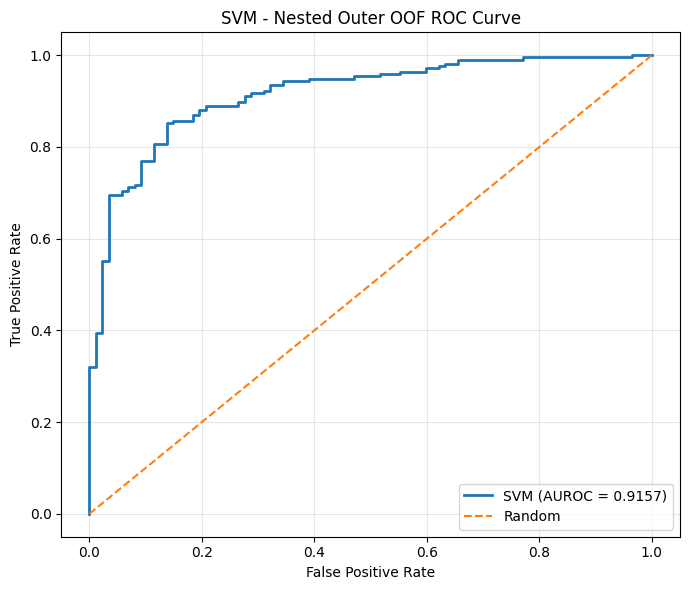

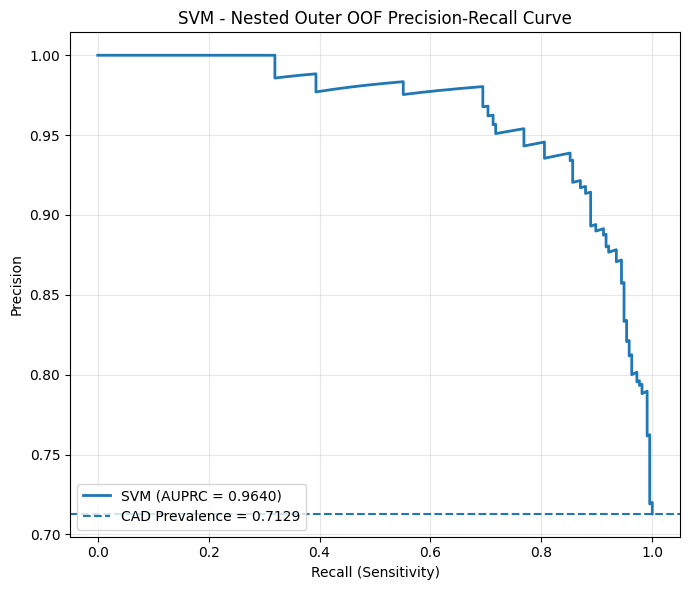

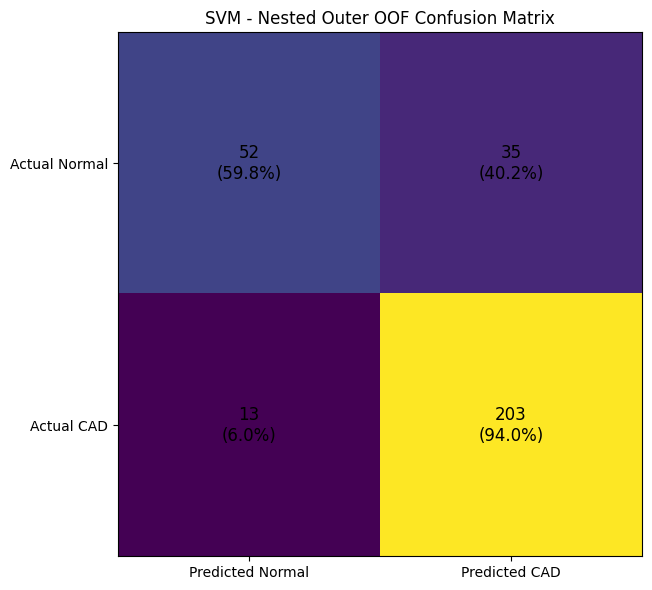

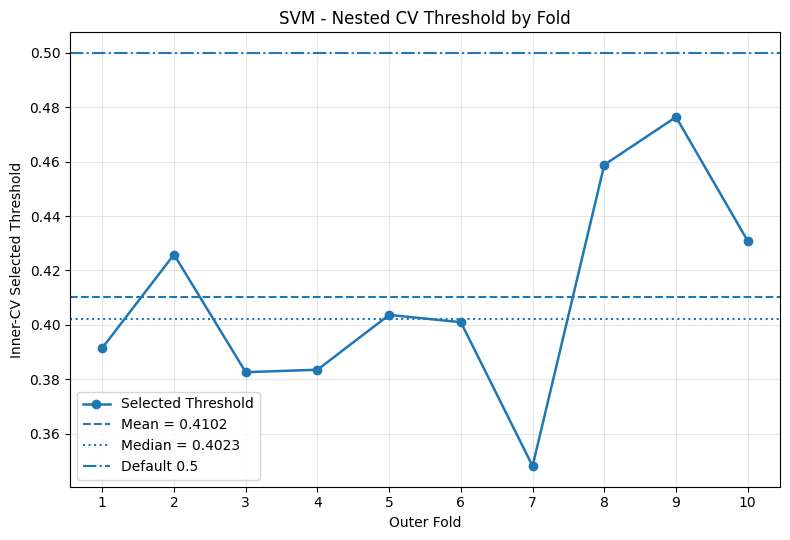

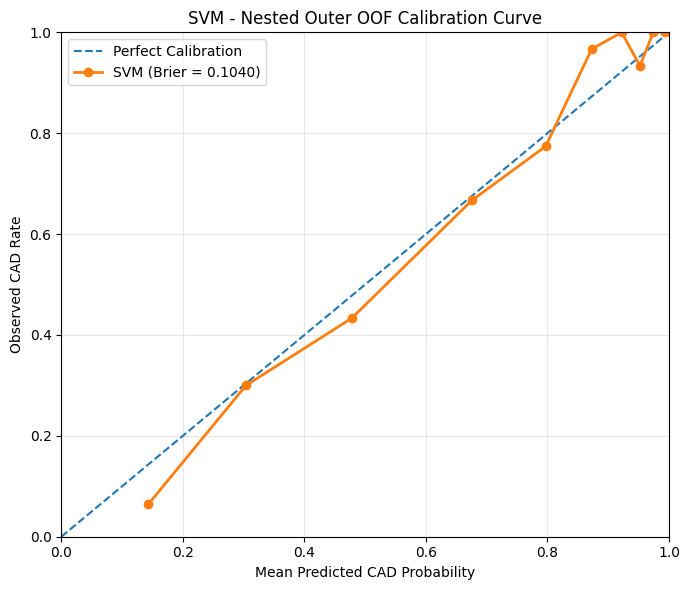


[1. Final Nested OOF Performance]


,AUROC,AUPRC,Accuracy,Precision,Sensitivity,Specificity,NPV,F1,TN,FP,FN,TP
0,0.915656,0.964048,0.841584,0.852941,0.939815,0.597701,0.8,0.894273,52,35,13,203



[2. Threshold Summary]
Mean   : 0.4102
Median : 0.4023
SD     : 0.0384
Min    : 0.3480
Max    : 0.4765

[3. Calibration Metrics]


,CAD Prevalence,Mean Predicted Probability,Brier Score,Baseline Brier Score,Brier Skill Score,Log Loss,ECE
0,0.712871,0.710528,0.10404,0.204686,0.491708,0.333502,0.038273



[4. Calibration Bins]


,Bin,N,Mean Predicted Probability,Actual CAD Rate,Absolute Calibration Gap
0,1,31,0.1433,0.0645,0.0788
1,2,30,0.3040,0.3000,0.0040
2,3,30,0.4780,0.4333,0.0447
3,4,30,0.6755,0.6667,0.0088
4,5,31,0.7971,0.7742,0.0229
5,6,30,0.8727,0.9667,0.0940
6,7,30,0.9221,1.0000,0.0779
7,8,30,0.9522,0.9333,0.0189
8,9,30,0.9741,1.0000,0.0259
9,10,31,0.9929,1.0000,0.0071



[5. Figures Saved]
ROC         : /content/drive/MyDrive/clinical_cad/results/svm/figures/01_svm_nested_outer_oof_roc.png
PR          : /content/drive/MyDrive/clinical_cad/results/svm/figures/02_svm_nested_outer_oof_pr_curve.png
CM          : /content/drive/MyDrive/clinical_cad/results/svm/figures/03_svm_nested_outer_oof_confusion_matrix.png
Threshold   : /content/drive/MyDrive/clinical_cad/results/svm/figures/04_svm_nested_threshold_by_fold.png
Calibration : /content/drive/MyDrive/clinical_cad/results/svm/figures/05_svm_nested_outer_oof_calibration_curve.png

✅ STEP SVM-5 Final SVM Visualization 완료


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss,
    log_loss
)

from sklearn.calibration import calibration_curve


# =============================================================================
# 입력 확인
# =============================================================================
y_true = np.asarray(
    y,
    dtype=int
)

y_prob = np.asarray(
    svm_nested_oof_proba,
    dtype=float
)

y_pred = np.asarray(
    svm_nested_oof_pred,
    dtype=int
)


assert len(y_true) == 303
assert len(y_prob) == 303
assert len(y_pred) == 303

assert np.isnan(y_prob).sum() == 0


print("=" * 100)
print("[0. Final SVM Nested OOF Input]")
print("=" * 100)

print(
    "Patients    :",
    len(y_true)
)

print(
    "Probability :",
    f"{y_prob.min():.6f}",
    "~",
    f"{y_prob.max():.6f}"
)


# =============================================================================
# 1. ROC CURVE
# =============================================================================

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    y_prob
)

svm_final_auroc = roc_auc_score(
    y_true,
    y_prob
)


plt.figure(
    figsize=(7, 6)
)

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        "SVM "
        f"(AUROC = {svm_final_auroc:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "SVM - Nested Outer OOF ROC Curve"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()


roc_figure_path = (
    SVM_FIGURE_DIR /
    "01_svm_nested_outer_oof_roc.png"
)

plt.savefig(
    roc_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


roc_table_path = (
    SVM_TABLE_DIR /
    "09_svm_nested_outer_oof_roc_curve.csv"
)

pd.DataFrame({
    "FPR": fpr,
    "TPR": tpr,
    "Threshold": roc_thresholds
}).to_csv(
    roc_table_path,
    index=False
)


# =============================================================================
# 2. PRECISION-RECALL CURVE
# =============================================================================

precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(
        y_true,
        y_prob
    )
)

svm_final_auprc = (
    average_precision_score(
        y_true,
        y_prob
    )
)

cad_prevalence = (
    y_true.mean()
)


plt.figure(
    figsize=(7, 6)
)

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=(
        "SVM "
        f"(AUPRC = {svm_final_auprc:.4f})"
    )
)

plt.axhline(
    y=cad_prevalence,
    linestyle="--",
    label=(
        "CAD Prevalence "
        f"= {cad_prevalence:.4f}"
    )
)

plt.xlabel(
    "Recall (Sensitivity)"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "SVM - Nested Outer OOF "
    "Precision-Recall Curve"
)

plt.legend(
    loc="lower left"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()


pr_figure_path = (
    SVM_FIGURE_DIR /
    "02_svm_nested_outer_oof_pr_curve.png"
)

plt.savefig(
    pr_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# threshold는 precision/recall보다 1개 짧으므로
# 동일 길이 구간만 저장
pr_table_path = (
    SVM_TABLE_DIR /
    "10_svm_nested_outer_oof_pr_curve.csv"
)

pd.DataFrame({
    "Recall":
        recall_curve[:-1],

    "Precision":
        precision_curve[:-1],

    "Threshold":
        pr_thresholds
}).to_csv(
    pr_table_path,
    index=False
)


# =============================================================================
# 3. CONFUSION MATRIX
# =============================================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        0,
        1
    ]
)

tn, fp, fn, tp = (
    cm.ravel()
)


sensitivity = (
    tp /
    (tp + fn)
)

specificity = (
    tn /
    (tn + fp)
)

precision_value = (
    tp /
    (tp + fp)
)

npv = (
    tn /
    (tn + fn)
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)


# 행 기준 비율
cm_percent = (
    cm /
    cm.sum(
        axis=1,
        keepdims=True
    )
    *
    100
)


fig, ax = plt.subplots(
    figsize=(7, 6)
)

image = ax.imshow(
    cm
)

ax.set_xticks(
    [
        0,
        1
    ]
)

ax.set_yticks(
    [
        0,
        1
    ]
)

ax.set_xticklabels(
    [
        "Predicted Normal",
        "Predicted CAD"
    ]
)

ax.set_yticklabels(
    [
        "Actual Normal",
        "Actual CAD"
    ]
)


for i in range(2):

    for j in range(2):

        ax.text(
            j,
            i,
            (
                f"{cm[i, j]}\n"
                f"({cm_percent[i, j]:.1f}%)"
            ),
            ha="center",
            va="center",
            fontsize=12
        )


ax.set_title(
    "SVM - Nested Outer OOF "
    "Confusion Matrix"
)

plt.tight_layout()


cm_figure_path = (
    SVM_FIGURE_DIR /
    "03_svm_nested_outer_oof_confusion_matrix.png"
)

plt.savefig(
    cm_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


cm_table_path = (
    SVM_TABLE_DIR /
    "11_svm_nested_outer_oof_confusion_matrix.csv"
)

pd.DataFrame(
    cm,
    index=[
        "Actual Normal",
        "Actual CAD"
    ],
    columns=[
        "Predicted Normal",
        "Predicted CAD"
    ]
).to_csv(
    cm_table_path
)


classification_metrics_df = pd.DataFrame(
    [
        {
            "AUROC":
                svm_final_auroc,

            "AUPRC":
                svm_final_auprc,

            "Accuracy":
                accuracy,

            "Precision":
                precision_value,

            "Sensitivity":
                sensitivity,

            "Specificity":
                specificity,

            "NPV":
                npv,

            "F1":
                f1,

            "TN":
                tn,

            "FP":
                fp,

            "FN":
                fn,

            "TP":
                tp
        }
    ]
)


classification_metrics_path = (
    SVM_TABLE_DIR /
    "12_svm_nested_outer_oof_classification_metrics.csv"
)

classification_metrics_df.to_csv(
    classification_metrics_path,
    index=False
)


# =============================================================================
# 4. FOLD-SPECIFIC THRESHOLD
# =============================================================================

threshold_df = (
    svm_nested_fold_results[
        [
            "Outer Fold",
            "Threshold",
            "Inner Sensitivity",
            "Inner Specificity"
        ]
    ]
    .copy()
)


threshold_mean = (
    threshold_df[
        "Threshold"
    ].mean()
)

threshold_median = (
    threshold_df[
        "Threshold"
    ].median()
)

threshold_sd = (
    threshold_df[
        "Threshold"
    ].std(
        ddof=1
    )
)


plt.figure(
    figsize=(8, 5.5)
)

plt.plot(
    threshold_df[
        "Outer Fold"
    ],
    threshold_df[
        "Threshold"
    ],
    marker="o",
    linewidth=1.8,
    label="Selected Threshold"
)

plt.axhline(
    threshold_mean,
    linestyle="--",
    label=(
        "Mean "
        f"= {threshold_mean:.4f}"
    )
)

plt.axhline(
    threshold_median,
    linestyle=":",
    label=(
        "Median "
        f"= {threshold_median:.4f}"
    )
)

plt.axhline(
    0.5,
    linestyle="-.",
    label="Default 0.5"
)


plt.xlabel(
    "Outer Fold"
)

plt.ylabel(
    "Inner-CV Selected Threshold"
)

plt.title(
    "SVM - Nested CV Threshold by Fold"
)

plt.xticks(
    threshold_df[
        "Outer Fold"
    ]
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()


threshold_figure_path = (
    SVM_FIGURE_DIR /
    "04_svm_nested_threshold_by_fold.png"
)

plt.savefig(
    threshold_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


threshold_table_path = (
    SVM_TABLE_DIR /
    "13_svm_nested_threshold_by_fold.csv"
)

threshold_df.to_csv(
    threshold_table_path,
    index=False
)


# =============================================================================
# 5. CALIBRATION
# =============================================================================

svm_brier = brier_score_loss(
    y_true,
    y_prob
)

svm_logloss = log_loss(
    y_true,
    y_prob
)


# -------------------------------------------------------------------------
# Prevalence-only baseline
# -------------------------------------------------------------------------

baseline_probability = np.full(
    len(y_true),
    cad_prevalence
)

baseline_brier = brier_score_loss(
    y_true,
    baseline_probability
)


brier_skill_score = (
    1
    -
    svm_brier /
    baseline_brier
)


# -------------------------------------------------------------------------
# 10 quantile calibration bins
# -------------------------------------------------------------------------

n_bins = 10


fraction_positive, mean_predicted = (
    calibration_curve(
        y_true,
        y_prob,
        n_bins=n_bins,
        strategy="quantile"
    )
)


# -------------------------------------------------------------------------
# ECE 계산
# -------------------------------------------------------------------------

quantile_edges = np.quantile(
    y_prob,
    np.linspace(
        0,
        1,
        n_bins + 1
    )
)

quantile_edges[0] = -np.inf
quantile_edges[-1] = np.inf


bin_indices = np.digitize(
    y_prob,
    quantile_edges[1:-1],
    right=True
)


calibration_rows = []

ece = 0.0


for bin_idx in range(
    n_bins
):

    mask = (
        bin_indices ==
        bin_idx
    )

    n = int(
        mask.sum()
    )

    if n == 0:
        continue


    mean_probability = (
        y_prob[
            mask
        ].mean()
    )


    actual_rate = (
        y_true[
            mask
        ].mean()
    )


    calibration_gap = abs(
        actual_rate
        -
        mean_probability
    )


    weight = (
        n /
        len(y_true)
    )


    ece += (
        weight *
        calibration_gap
    )


    calibration_rows.append({
        "Bin":
            bin_idx + 1,

        "N":
            n,

        "Mean Predicted Probability":
            mean_probability,

        "Actual CAD Rate":
            actual_rate,

        "Absolute Calibration Gap":
            calibration_gap
    })


svm_calibration_bins = pd.DataFrame(
    calibration_rows
)


svm_calibration_metrics = pd.DataFrame(
    [
        {
            "CAD Prevalence":
                cad_prevalence,

            "Mean Predicted Probability":
                y_prob.mean(),

            "Brier Score":
                svm_brier,

            "Baseline Brier Score":
                baseline_brier,

            "Brier Skill Score":
                brier_skill_score,

            "Log Loss":
                svm_logloss,

            "ECE":
                ece
        }
    ]
)


plt.figure(
    figsize=(7, 6)
)

plt.plot(
    [
        0,
        1
    ],
    [
        0,
        1
    ],
    linestyle="--",
    label="Perfect Calibration"
)

plt.plot(
    mean_predicted,
    fraction_positive,
    marker="o",
    linewidth=2,
    label=(
        "SVM "
        f"(Brier = {svm_brier:.4f})"
    )
)

plt.xlabel(
    "Mean Predicted CAD Probability"
)

plt.ylabel(
    "Observed CAD Rate"
)

plt.title(
    "SVM - Nested Outer OOF "
    "Calibration Curve"
)

plt.xlim(
    0,
    1
)

plt.ylim(
    0,
    1
)

plt.grid(
    alpha=0.3
)

plt.legend(
    loc="best"
)

plt.tight_layout()


calibration_figure_path = (
    SVM_FIGURE_DIR /
    "05_svm_nested_outer_oof_calibration_curve.png"
)

plt.savefig(
    calibration_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


calibration_metrics_path = (
    SVM_TABLE_DIR /
    "14_svm_nested_outer_oof_calibration_metrics.csv"
)

calibration_bins_path = (
    SVM_TABLE_DIR /
    "15_svm_nested_outer_oof_calibration_bins.csv"
)


svm_calibration_metrics.to_csv(
    calibration_metrics_path,
    index=False
)

svm_calibration_bins.to_csv(
    calibration_bins_path,
    index=False
)


# =============================================================================
# 6. 최종 출력
# =============================================================================

print()
print("=" * 100)
print("[1. Final Nested OOF Performance]")
print("=" * 100)

display(
    classification_metrics_df.round(
        6
    )
)


print()
print("=" * 100)
print("[2. Threshold Summary]")
print("=" * 100)

print(
    f"Mean   : {threshold_mean:.4f}"
)

print(
    f"Median : {threshold_median:.4f}"
)

print(
    f"SD     : {threshold_sd:.4f}"
)

print(
    f"Min    : "
    f"{threshold_df['Threshold'].min():.4f}"
)

print(
    f"Max    : "
    f"{threshold_df['Threshold'].max():.4f}"
)


print()
print("=" * 100)
print("[3. Calibration Metrics]")
print("=" * 100)

display(
    svm_calibration_metrics.round(
        6
    )
)


print()
print("=" * 100)
print("[4. Calibration Bins]")
print("=" * 100)

display(
    svm_calibration_bins.round(
        4
    )
)


print()
print("=" * 100)
print("[5. Figures Saved]")
print("=" * 100)

print(
    "ROC         :",
    roc_figure_path
)

print(
    "PR          :",
    pr_figure_path
)

print(
    "CM          :",
    cm_figure_path
)

print(
    "Threshold   :",
    threshold_figure_path
)

print(
    "Calibration :",
    calibration_figure_path
)


print()
print(
    "✅ STEP SVM-5 "
    "Final SVM Visualization 완료"
)

# Final SVM Hyperparameter Selection

In [ ]:

# -----------------------------------------------------------------------------
# 1. Library
# -----------------------------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.base import clone

from sklearn.pipeline import Pipeline

from sklearn.svm import SVC

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)

# =============================================================================
# 2. Final SVM Search Pipeline
# =============================================================================

svm_final_search_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),

        (
            "model",
            SVC(
                probability=False,
                cache_size=1000
            )
        )
    ]
)


# =============================================================================
# 3. Search Space
# =============================================================================

svm_final_param_grid = [

    # -------------------------------------------------------------------------
    # Linear SVM
    # -------------------------------------------------------------------------
    {
        "model__kernel": [
            "linear"
        ],

        "model__C": [
            0.01,
            0.1,
            1,
            10,
            100
        ],

        "model__class_weight": [
            None,
            "balanced"
        ]
    },


    # -------------------------------------------------------------------------
    # RBF SVM
    # -------------------------------------------------------------------------
    {
        "model__kernel": [
            "rbf"
        ],

        "model__C": [
            0.1,
            1,
            10,
            100
        ],

        "model__gamma": [
            "scale",
            0.01,
            0.1,
            1
        ],

        "model__class_weight": [
            None,
            "balanced"
        ]
    }
]


# =============================================================================
# 4. Final Parameter Selection CV
# =============================================================================

svm_final_selection_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


# =============================================================================
# 5. Grid Search 실행
# =============================================================================

svm_final_grid = GridSearchCV(
    estimator=svm_final_search_pipeline,

    param_grid=svm_final_param_grid,

    scoring="roc_auc",

    cv=svm_final_selection_cv,

    refit=True,

    n_jobs=-1,

    return_train_score=True
)


svm_final_grid.fit(
    X_baseline,
    y
)


# =============================================================================
# 6. Best Hyperparameter
# =============================================================================

best_params = (
    svm_final_grid.best_params_
)


FINAL_SVM_KERNEL = (
    best_params[
        "model__kernel"
    ]
)


FINAL_SVM_C = (
    best_params[
        "model__C"
    ]
)


FINAL_SVM_CLASS_WEIGHT = (
    best_params[
        "model__class_weight"
    ]
)


FINAL_SVM_GAMMA = (
    best_params.get(
        "model__gamma",
        None
    )
)


print("=" * 100)
print("[1. Final SVM Hyperparameter]")
print("=" * 100)

print(
    "Best Kernel       :",
    FINAL_SVM_KERNEL
)

print(
    "Best C            :",
    FINAL_SVM_C
)

print(
    "Best Gamma        :",
    FINAL_SVM_GAMMA
)

print(
    "Best Class Weight :",
    FINAL_SVM_CLASS_WEIGHT
)

print(
    "Best CV AUROC     :",
    round(
        svm_final_grid.best_score_,
        6
    )
)


# =============================================================================
# 7. 전체 Grid Search 결과 정리
# =============================================================================

grid_results = pd.DataFrame(
    svm_final_grid.cv_results_
)


# RBF가 아닌 Linear row에서는 gamma가 NaN이 될 수 있다.
final_grid_table = pd.DataFrame({

    "Kernel":
        grid_results[
            "param_model__kernel"
        ],

    "C":
        grid_results[
            "param_model__C"
        ],

    "Gamma":
        grid_results.get(
            "param_model__gamma",
            pd.Series(
                [np.nan] *
                len(grid_results)
            )
        ),

    "Class Weight":
        grid_results[
            "param_model__class_weight"
        ],

    "Train AUROC Mean":
        grid_results[
            "mean_train_score"
        ],

    "Train AUROC SD":
        grid_results[
            "std_train_score"
        ],

    "CV AUROC Mean":
        grid_results[
            "mean_test_score"
        ],

    "CV AUROC SD":
        grid_results[
            "std_test_score"
        ],

    "Rank":
        grid_results[
            "rank_test_score"
        ]
})


final_grid_table = (
    final_grid_table
    .sort_values(
        by=[
            "Rank",
            "CV AUROC Mean"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


# Train / Validation gap 추가
final_grid_table[
    "Train-Val AUROC Gap"
] = (
    final_grid_table[
        "Train AUROC Mean"
    ]
    -
    final_grid_table[
        "CV AUROC Mean"
    ]
)


print()
print("=" * 100)
print("[2. Top 15 Grid Search Results]")
print("=" * 100)

display(
    final_grid_table
    .head(15)
    .round(6)
)


# =============================================================================
# 8. Kernel별 최고 결과
# =============================================================================

best_by_kernel = (
    final_grid_table
    .sort_values(
        "Rank"
    )
    .groupby(
        "Kernel",
        as_index=False
    )
    .first()
)


print()
print("=" * 100)
print("[3. Best Result by Kernel]")
print("=" * 100)

display(
    best_by_kernel[
        [
            "Kernel",
            "C",
            "Gamma",
            "Class Weight",
            "CV AUROC Mean",
            "CV AUROC SD",
            "Train AUROC Mean",
            "Train-Val AUROC Gap",
            "Rank"
        ]
    ].round(6)
)


# =============================================================================
# 9. 결과 저장
# =============================================================================

final_grid_path = (
    SVM_TABLE_DIR /
    "16_svm_final_grid_search_results.csv"
)


final_parameter_path = (
    SVM_TABLE_DIR /
    "17_svm_final_best_hyperparameters.csv"
)


final_grid_table.to_csv(
    final_grid_path,
    index=False
)


final_parameter_df = pd.DataFrame(
    [
        {
            "Kernel":
                FINAL_SVM_KERNEL,

            "C":
                FINAL_SVM_C,

            "Gamma":
                FINAL_SVM_GAMMA,

            "Class Weight":
                FINAL_SVM_CLASS_WEIGHT,

            "Selection Metric":
                "AUROC",

            "5-Fold CV AUROC":
                svm_final_grid.best_score_
        }
    ]
)


final_parameter_df.to_csv(
    final_parameter_path,
    index=False
)


# =============================================================================
# 10. 저장 결과
# =============================================================================

print()
print("=" * 100)
print("[저장 완료]")
print("=" * 100)

print(
    "Grid Search Results :",
    final_grid_path
)

print(
    "Best Hyperparameter :",
    final_parameter_path
)


print()
print(
    "✅ STEP SVM-6 "
    "Final SVM Hyperparameter Selection 완료"
)

print()

print(
    "※ 위 CV AUROC는 Final parameter 선택용이며 "
    "최종 성능으로 보고하지 않습니다."
)

print(
    "※ 최종 SVM 성능은 Nested CV Outer Validation 결과인"
)

print(
    "   AUROC 0.915656 / "
    "AUPRC 0.964048을 사용합니다."
)

[1. Final SVM Hyperparameter]
Best Kernel       : linear
Best C            : 0.1
Best Gamma        : None
Best Class Weight : None
Best CV AUROC     : 0.928754

[2. Top 15 Grid Search Results]


,Kernel,C,Gamma,Class Weight,Train AUROC Mean,Train AUROC SD,CV AUROC Mean,CV AUROC SD,Rank,Train-Val AUROC Gap
0,linear,0.1,NaN,None,0.965261,0.005761,0.928754,0.029870,1,0.036507
1,rbf,10.0,0.01,None,0.991563,0.003009,0.926244,0.031095,2,0.065319
2,rbf,10.0,0.01,balanced,0.995546,0.001968,0.923593,0.032625,3,0.071953
3,linear,0.1,NaN,balanced,0.968022,0.005517,0.919799,0.038547,4,0.048222
4,rbf,1.0,0.01,balanced,0.965992,0.008061,0.916804,0.045065,5,0.049188
5,rbf,1.0,0.01,None,0.961333,0.007766,0.916788,0.034385,6,0.044546
6,rbf,100.0,0.01,None,1.000000,0.000000,0.916533,0.024561,7,0.083467
7,linear,1.0,NaN,balanced,0.975798,0.003926,0.916117,0.038691,8,0.059681
8,rbf,100.0,0.01,balanced,1.000000,0.000000,0.915518,0.025053,9,0.084482
9,rbf,1.0,scale,balanced,0.991487,0.002771,0.914921,0.041487,10,0.076566



[3. Best Result by Kernel]


,Kernel,C,Gamma,Class Weight,CV AUROC Mean,CV AUROC SD,Train AUROC Mean,Train-Val AUROC Gap,Rank
0,linear,0.1,None,balanced,0.928754,0.029870,0.965261,0.036507,1
1,rbf,10.0,0.01,balanced,0.926244,0.031095,0.991563,0.065319,2



[저장 완료]
Grid Search Results : /content/drive/MyDrive/clinical_cad/results/svm/tables/16_svm_final_grid_search_results.csv
Best Hyperparameter : /content/drive/MyDrive/clinical_cad/results/svm/tables/17_svm_final_best_hyperparameters.csv

✅ STEP SVM-6 Final SVM Hyperparameter Selection 완료

※ 위 CV AUROC는 Final parameter 선택용이며 최종 성능으로 보고하지 않습니다.
※ 최종 SVM 성능은 Nested CV Outer Validation 결과인
   AUROC 0.915656 / AUPRC 0.964048을 사용합니다.


In [ ]:
# Best Result by Kernel Summary 수정


# -----------------------------------------------------------------------------
# 1. Rank 기준으로 정렬한 뒤
#    Kernel별 실제 첫 번째 ROW 자체를 선택
# -----------------------------------------------------------------------------

best_by_kernel = (
    final_grid_table
    .sort_values(
        by=[
            "Rank",
            "CV AUROC Mean"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "Kernel",
        group_keys=False
    )
    .head(1)
    .reset_index(
        drop=True
    )
)


# -----------------------------------------------------------------------------
# 2. 정확한 결과 확인
# -----------------------------------------------------------------------------

print("=" * 100)
print("[Corrected Best Result by Kernel]")
print("=" * 100)

display(
    best_by_kernel[
        [
            "Kernel",
            "C",
            "Gamma",
            "Class Weight",
            "CV AUROC Mean",
            "CV AUROC SD",
            "Train AUROC Mean",
            "Train-Val AUROC Gap",
            "Rank"
        ]
    ].round(6)
)


# -----------------------------------------------------------------------------
# 3. Final selected parameter 재확인
# -----------------------------------------------------------------------------

print()
print("=" * 100)
print("[Final Selected SVM]")
print("=" * 100)

print(
    "Kernel       :",
    FINAL_SVM_KERNEL
)

print(
    "C            :",
    FINAL_SVM_C
)

print(
    "Gamma        :",
    FINAL_SVM_GAMMA
)

print(
    "Class Weight :",
    FINAL_SVM_CLASS_WEIGHT
)

print(
    "CV AUROC     :",
    round(
        svm_final_grid.best_score_,
        6
    )
)


# -----------------------------------------------------------------------------
# 4. 수정된 Kernel별 결과 저장
# -----------------------------------------------------------------------------

best_by_kernel_path = (
    SVM_TABLE_DIR /
    "18_svm_final_best_result_by_kernel.csv"
)

best_by_kernel.to_csv(
    best_by_kernel_path,
    index=False
)


print()
print(
    "Saved :",
    best_by_kernel_path
)

print()
print(
    "✅ STEP SVM-6-FIX 완료"
)

[Corrected Best Result by Kernel]


,Kernel,C,Gamma,Class Weight,CV AUROC Mean,CV AUROC SD,Train AUROC Mean,Train-Val AUROC Gap,Rank
0,linear,0.1,NaN,None,0.928754,0.029870,0.965261,0.036507,1
1,rbf,10.0,0.01,None,0.926244,0.031095,0.991563,0.065319,2



[Final Selected SVM]
Kernel       : linear
C            : 0.1
Gamma        : None
Class Weight : None
CV AUROC     : 0.928754

Saved : /content/drive/MyDrive/clinical_cad/results/svm/tables/18_svm_final_best_result_by_kernel.csv

✅ STEP SVM-6-FIX 완료


# 최종 SVM 후보 선정 , Calibrated OOF Probability 생성

In [ ]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.model_selection import (
    StratifiedKFold
)

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss
)


# =============================================================================
# 최종 SVM parameter 확인
# =============================================================================

assert FINAL_SVM_KERNEL == "linear"
assert FINAL_SVM_C == 0.1
assert FINAL_SVM_CLASS_WEIGHT is None


print("=" * 100)
print("[1. Fixed Final SVM Candidate]")
print("=" * 100)

print(
    "Kernel       :",
    FINAL_SVM_KERNEL
)

print(
    "C            :",
    FINAL_SVM_C
)

print(
    "Gamma        :",
    FINAL_SVM_GAMMA
)

print(
    "Class Weight :",
    FINAL_SVM_CLASS_WEIGHT
)


# =============================================================================
# Fixed Final SVM Pipeline
# =============================================================================

svm_final_base_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),

        (
            "model",
            SVC(
                kernel="linear",
                C=0.1,
                class_weight=None,
                probability=False,
                cache_size=1000
            )
        )
    ]
)


# =============================================================================
# 4. OOF CV
# =============================================================================


svm_final_oof_cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)


# OOF probability 저장
svm_final_oof_proba = np.full(
    len(X_baseline),
    np.nan,
    dtype=float
)


# fold 정보 저장
svm_final_oof_fold = np.full(
    len(X_baseline),
    -1,
    dtype=int
)


# =============================================================================
# 5. Fold Loop
# =============================================================================

for fold, (
    train_idx,
    valid_idx
) in enumerate(
    svm_final_oof_cv.split(
        X_baseline,
        y
    ),
    start=1
):

    print(
        f"Fold {fold:02d}/10",
        end="  "
    )


    X_train = (
        X_baseline.iloc[
            train_idx
        ]
    )

    X_valid = (
        X_baseline.iloc[
            valid_idx
        ]
    )

    y_train = (
        y.iloc[
            train_idx
        ]
    )


    # -------------------------------------------------------------------------
    # Calibration CV
    # -------------------------------------------------------------------------

    calibration_cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=(
            RANDOM_STATE
            +
            100
            +
            fold
        )
    )


    calibrated_model = CalibratedClassifierCV(
        estimator=clone(
            svm_final_base_pipeline
        ),

        method="sigmoid",

        cv=calibration_cv,

        ensemble=True,

        n_jobs=1
    )


    # -------------------------------------------------------------------------
    # Training fold에만 fit
    # -------------------------------------------------------------------------

    calibrated_model.fit(
        X_train,
        y_train
    )


    # -------------------------------------------------------------------------
    # 해당 validation fold probability
    # -------------------------------------------------------------------------

    fold_proba = (
        calibrated_model
        .predict_proba(
            X_valid
        )[:, 1]
    )


    svm_final_oof_proba[
        valid_idx
    ] = fold_proba


    svm_final_oof_fold[
        valid_idx
    ] = fold


    print(
        f"N_train={len(train_idx):3d} | "
        f"N_valid={len(valid_idx):2d} | "
        f"P_mean={fold_proba.mean():.4f}"
    )


# =============================================================================
# 6. OOF 완성 검증
# =============================================================================

assert np.isnan(
    svm_final_oof_proba
).sum() == 0


assert np.all(
    svm_final_oof_fold >= 1
)


assert len(
    svm_final_oof_proba
) == 303


# =============================================================================
# 7. Threshold-setting reference metrics
# =============================================================================

svm_final_oof_auroc = roc_auc_score(
    y,
    svm_final_oof_proba
)


svm_final_oof_auprc = average_precision_score(
    y,
    svm_final_oof_proba
)


svm_final_oof_brier = brier_score_loss(
    y,
    svm_final_oof_proba
)


svm_final_oof_logloss = log_loss(
    y,
    svm_final_oof_proba
)


# =============================================================================
# 8. 환자별 OOF Probability 저장
# =============================================================================

svm_final_candidate_oof_df = pd.DataFrame({

    "Patient_Index":
        X_baseline.index,

    "True_Label":
        np.asarray(y),

    "OOF_Fold":
        svm_final_oof_fold,

    "Final_SVM_OOF_Probability":
        svm_final_oof_proba
})


oof_probability_path = (
    SVM_TABLE_DIR /
    "19_svm_final_candidate_oof_probability.csv"
)


svm_final_candidate_oof_df.to_csv(
    oof_probability_path,
    index=False
)


# =============================================================================
# 9. Summary 저장
# =============================================================================

svm_final_candidate_oof_summary = pd.DataFrame(
    [
        {
            "Kernel":
                "linear",

            "C":
                0.1,

            "Class Weight":
                None,

            "Calibration":
                "Sigmoid",

            "OOF CV":
                "Stratified 10-Fold",

            "N":
                len(y),

            "Probability Min":
                svm_final_oof_proba.min(),

            "Probability Max":
                svm_final_oof_proba.max(),

            "Probability Mean":
                svm_final_oof_proba.mean(),

            "OOF AUROC":
                svm_final_oof_auroc,

            "OOF AUPRC":
                svm_final_oof_auprc,

            "Brier Score":
                svm_final_oof_brier,

            "Log Loss":
                svm_final_oof_logloss
        }
    ]
)


oof_summary_path = (
    SVM_TABLE_DIR /
    "20_svm_final_candidate_oof_summary.csv"
)


svm_final_candidate_oof_summary.to_csv(
    oof_summary_path,
    index=False
)


# =============================================================================
# 10. 결과 출력
# =============================================================================

print()
print("=" * 100)
print("[2. Fixed Final SVM - Calibrated OOF Probability]")
print("=" * 100)

print(
    "Patients         :",
    len(
        svm_final_oof_proba
    )
)

print(
    "Probability Min  :",
    f"{svm_final_oof_proba.min():.6f}"
)

print(
    "Probability Max  :",
    f"{svm_final_oof_proba.max():.6f}"
)

print(
    "Probability Mean :",
    f"{svm_final_oof_proba.mean():.6f}"
)


print()
print(
    "OOF AUROC        :",
    f"{svm_final_oof_auroc:.6f}"
)

print(
    "OOF AUPRC        :",
    f"{svm_final_oof_auprc:.6f}"
)

print(
    "Brier Score      :",
    f"{svm_final_oof_brier:.6f}"
)

print(
    "Log Loss         :",
    f"{svm_final_oof_logloss:.6f}"
)


print()
print("=" * 100)
print("[3. Saved]")
print("=" * 100)

print(
    "OOF Probability :",
    oof_probability_path
)

print(
    "OOF Summary     :",
    oof_summary_path
)


print()
print(
    "✅ STEP SVM-7 "
    "Fixed Final SVM Calibrated OOF Probability 완료"
)

print()
print(
    "※ 위 AUROC/AUPRC는 operational threshold 설정용 reference입니다."
)

print(
    "※ SVM 최종 보고 성능은 Nested Outer OOF "
    "AUROC 0.915656 / AUPRC 0.964048을 유지합니다."
)

[1. Fixed Final SVM Candidate]
Kernel       : linear
C            : 0.1
Gamma        : None
Class Weight : None
Fold 01/10  N_train=272 | N_valid=31 | P_mean=0.7198
Fold 02/10  N_train=272 | N_valid=31 | P_mean=0.6943
Fold 03/10  N_train=272 | N_valid=31 | P_mean=0.7288
Fold 04/10  N_train=273 | N_valid=30 | P_mean=0.7936
Fold 05/10  N_train=273 | N_valid=30 | P_mean=0.6548
Fold 06/10  N_train=273 | N_valid=30 | P_mean=0.7570
Fold 07/10  N_train=273 | N_valid=30 | P_mean=0.6861
Fold 08/10  N_train=273 | N_valid=30 | P_mean=0.6746
Fold 09/10  N_train=273 | N_valid=30 | P_mean=0.6406
Fold 10/10  N_train=273 | N_valid=30 | P_mean=0.7767

[2. Fixed Final SVM - Calibrated OOF Probability]
Patients         : 303
Probability Min  : 0.057283
Probability Max  : 0.999245
Probability Mean : 0.712638

OOF AUROC        : 0.928427
OOF AUPRC        : 0.970526
Brier Score      : 0.097879
Log Loss         : 0.316173

[3. Saved]
OOF Probability : /content/drive/MyDrive/clinical_cad/results/svm/tables/19

# Final SVM Operational Threshold Selection

In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# =============================================================================
# Threshold Target
# =============================================================================

SVM_OPERATIONAL_SENSITIVITY_TARGET = 0.95


# =============================================================================
# 입력
# =============================================================================

y_threshold = np.asarray(
    y,
    dtype=int
)

proba_threshold = np.asarray(
    svm_final_oof_proba,
    dtype=float
)


assert len(y_threshold) == 303
assert len(proba_threshold) == 303
assert np.isnan(proba_threshold).sum() == 0


# =============================================================================
# 모든 가능한 Threshold 평가
# =============================================================================
candidate_thresholds = np.sort(
    np.unique(
        proba_threshold
    )
)


threshold_rows = []


for threshold in candidate_thresholds:

    pred = (
        proba_threshold >= threshold
    ).astype(int)


    tn, fp, fn, tp = confusion_matrix(
        y_threshold,
        pred,
        labels=[0, 1]
    ).ravel()


    sensitivity = (
        tp / (tp + fn)
    )

    specificity = (
        tn / (tn + fp)
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )

    npv = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else np.nan
    )

    accuracy = (
        (tp + tn) /
        (tp + tn + fp + fn)
    )

    f1 = (
        2 * precision * sensitivity /
        (precision + sensitivity)
        if (
            precision + sensitivity
        ) > 0
        else np.nan
    )


    threshold_rows.append({

        "Threshold":
            threshold,

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "Precision":
            precision,

        "NPV":
            npv,

        "Accuracy":
            accuracy,

        "F1":
            f1,

        "TN":
            tn,

        "FP":
            fp,

        "FN":
            fn,

        "TP":
            tp
    })


svm_threshold_all = pd.DataFrame(
    threshold_rows
)


# =============================================================================
# Sensitivity >= 95% 후보만 선택
# =============================================================================

eligible_thresholds = (
    svm_threshold_all[
        svm_threshold_all[
            "Sensitivity"
        ]
        >=
        SVM_OPERATIONAL_SENSITIVITY_TARGET
    ]
    .copy()
)


assert len(
    eligible_thresholds
) > 0, (
    "Sensitivity >= 95%를 만족하는 threshold가 없습니다."
)


# =============================================================================
# 최종 Operational Threshold 선택
# =============================================================================

eligible_thresholds = (
    eligible_thresholds
    .sort_values(
        by=[
            "Specificity",
            "Threshold"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


selected_row = (
    eligible_thresholds.iloc[0]
)


FINAL_SVM_THRESHOLD = float(
    selected_row[
        "Threshold"
    ]
)


# =============================================================================
# 7. 최종 Threshold 성능
# =============================================================================

final_svm_threshold_pred = (
    proba_threshold
    >= FINAL_SVM_THRESHOLD
).astype(int)


final_tn, final_fp, final_fn, final_tp = (
    confusion_matrix(
        y_threshold,
        final_svm_threshold_pred,
        labels=[0, 1]
    ).ravel()
)


final_sensitivity = (
    final_tp /
    (final_tp + final_fn)
)

final_specificity = (
    final_tn /
    (final_tn + final_fp)
)

final_precision = (
    final_tp /
    (final_tp + final_fp)
)

final_npv = (
    final_tn /
    (final_tn + final_fn)
)

final_accuracy = accuracy_score(
    y_threshold,
    final_svm_threshold_pred
)

final_f1 = f1_score(
    y_threshold,
    final_svm_threshold_pred
)


# =============================================================================
# 8. Default Threshold 0.5 비교
# =============================================================================

default_threshold = 0.5


default_pred = (
    proba_threshold >= default_threshold
).astype(int)


default_tn, default_fp, default_fn, default_tp = (
    confusion_matrix(
        y_threshold,
        default_pred,
        labels=[0, 1]
    ).ravel()
)


default_sensitivity = (
    default_tp /
    (default_tp + default_fn)
)

default_specificity = (
    default_tn /
    (default_tn + default_fp)
)

default_precision = (
    default_tp /
    (default_tp + default_fp)
)

default_npv = (
    default_tn /
    (default_tn + default_fn)
)

default_accuracy = accuracy_score(
    y_threshold,
    default_pred
)

default_f1 = f1_score(
    y_threshold,
    default_pred
)


# =============================================================================
# 9. Threshold 비교표
# =============================================================================

threshold_comparison = pd.DataFrame([

    {
        "Policy":
            "Default 0.5",

        "Threshold":
            0.5,

        "Sensitivity":
            default_sensitivity,

        "Specificity":
            default_specificity,

        "Precision":
            default_precision,

        "NPV":
            default_npv,

        "Accuracy":
            default_accuracy,

        "F1":
            default_f1,

        "TN":
            default_tn,

        "FP":
            default_fp,

        "FN":
            default_fn,

        "TP":
            default_tp
    },


    {
        "Policy":
            "Sensitivity >= 95%",

        "Threshold":
            FINAL_SVM_THRESHOLD,

        "Sensitivity":
            final_sensitivity,

        "Specificity":
            final_specificity,

        "Precision":
            final_precision,

        "NPV":
            final_npv,

        "Accuracy":
            final_accuracy,

        "F1":
            final_f1,

        "TN":
            final_tn,

        "FP":
            final_fp,

        "FN":
            final_fn,

        "TP":
            final_tp
    }

])


# =============================================================================
# 10. 최종 threshold 주변 후보 확인
# =============================================================================

sorted_by_threshold = (
    svm_threshold_all
    .sort_values(
        "Threshold"
    )
    .reset_index(
        drop=True
    )
)


selected_index = int(
    np.argmin(
        np.abs(
            sorted_by_threshold[
                "Threshold"
            ].to_numpy()
            -
            FINAL_SVM_THRESHOLD
        )
    )
)


start_idx = max(
    0,
    selected_index - 5
)

end_idx = min(
    len(sorted_by_threshold),
    selected_index + 6
)


threshold_neighbors = (
    sorted_by_threshold
    .iloc[
        start_idx:end_idx
    ]
    .copy()
)


# 선택된 행 표시
threshold_neighbors[
    "Selected"
] = np.isclose(
    threshold_neighbors[
        "Threshold"
    ],
    FINAL_SVM_THRESHOLD
)


# =============================================================================
# 11. 저장용 최종 threshold DataFrame
# =============================================================================

final_threshold_df = pd.DataFrame(
    [
        {
            "Kernel":
                "linear",

            "C":
                0.1,

            "Class Weight":
                None,

            "Calibration":
                "Sigmoid",

            "Sensitivity Target":
                0.95,

            "Operational Threshold":
                FINAL_SVM_THRESHOLD,

            "Sensitivity":
                final_sensitivity,

            "Specificity":
                final_specificity,

            "Precision":
                final_precision,

            "NPV":
                final_npv,

            "Accuracy":
                final_accuracy,

            "F1":
                final_f1,

            "TN":
                final_tn,

            "FP":
                final_fp,

            "FN":
                final_fn,

            "TP":
                final_tp
        }
    ]
)


# =============================================================================
# 12. 결과 출력
# =============================================================================

print("=" * 100)
print("[1. FINAL SVM OPERATIONAL THRESHOLD]")
print("=" * 100)

print(
    "Threshold   :",
    f"{FINAL_SVM_THRESHOLD:.6f}"
)

print(
    "Sensitivity :",
    f"{final_sensitivity:.6f}"
)

print(
    "Specificity :",
    f"{final_specificity:.6f}"
)

print(
    "Precision   :",
    f"{final_precision:.6f}"
)

print(
    "NPV         :",
    f"{final_npv:.6f}"
)

print(
    "Accuracy    :",
    f"{final_accuracy:.6f}"
)

print(
    "F1          :",
    f"{final_f1:.6f}"
)

print()

print(
    "TN / FP / FN / TP :",
    final_tn,
    "/",
    final_fp,
    "/",
    final_fn,
    "/",
    final_tp
)


print()
print("=" * 100)
print("[2. Default 0.5 vs Operational Threshold]")
print("=" * 100)

display(
    threshold_comparison.round(6)
)


print()
print("=" * 100)
print("[3. Selected Threshold 주변 후보]")
print("=" * 100)

display(
    threshold_neighbors[
        [
            "Threshold",
            "Sensitivity",
            "Specificity",
            "TN",
            "FP",
            "FN",
            "TP",
            "Selected"
        ]
    ].round(6)
)


# =============================================================================
# 13. 결과 저장
# =============================================================================

final_threshold_path = (
    SVM_TABLE_DIR /
    "21_svm_final_operational_threshold.csv"
)


threshold_comparison_path = (
    SVM_TABLE_DIR /
    "22_svm_final_threshold_comparison.csv"
)


all_threshold_path = (
    SVM_TABLE_DIR /
    "23_svm_final_threshold_all_candidates.csv"
)


neighbor_threshold_path = (
    SVM_TABLE_DIR /
    "24_svm_final_threshold_neighbors.csv"
)


final_threshold_df.to_csv(
    final_threshold_path,
    index=False
)


threshold_comparison.to_csv(
    threshold_comparison_path,
    index=False
)


svm_threshold_all.to_csv(
    all_threshold_path,
    index=False
)


threshold_neighbors.to_csv(
    neighbor_threshold_path,
    index=False
)


print()
print("=" * 100)
print("[4. Saved]")
print("=" * 100)

print(
    "Final Threshold :",
    final_threshold_path
)

print(
    "Comparison      :",
    threshold_comparison_path
)

print(
    "All Candidates  :",
    all_threshold_path
)

print(
    "Neighbors       :",
    neighbor_threshold_path
)


print()
print(
    "✅ STEP SVM-8 "
    "Final Operational Threshold Selection 완료"
)

print()
print(
    "※ 이 threshold는 fixed final SVM candidate의 "
    "OOF probability로 결정했습니다."
)

print(
    "※ threshold reference 성능을 Nested Outer CV "
    "최종 일반화 성능과 혼동하지 않습니다."
)

[1. FINAL SVM OPERATIONAL THRESHOLD]
Threshold   : 0.382275
Sensitivity : 0.953704
Specificity : 0.586207
Precision   : 0.851240
NPV         : 0.836066
Accuracy    : 0.848185
F1          : 0.899563

TN / FP / FN / TP : 51 / 36 / 10 / 206

[2. Default 0.5 vs Operational Threshold]


,Policy,Threshold,Sensitivity,Specificity,Precision,NPV,Accuracy,F1,TN,FP,FN,TP
0,Default 0.5,0.500000,0.925926,0.701149,0.884956,0.792208,0.861386,0.904977,61,26,16,200
1,Sensitivity >= 95%,0.382275,0.953704,0.586207,0.851240,0.836066,0.848185,0.899563,51,36,10,206



[3. Selected Threshold 주변 후보]


,Threshold,Sensitivity,Specificity,TN,FP,FN,TP,Selected
56,0.335553,0.958333,0.540230,47,40,9,207,False
57,0.347337,0.958333,0.551724,48,39,9,207,False
58,0.348535,0.958333,0.563218,49,38,9,207,False
59,0.359528,0.958333,0.574713,50,37,9,207,False
60,0.382206,0.953704,0.574713,50,37,10,206,False
61,0.382275,0.953704,0.586207,51,36,10,206,True
62,0.385693,0.949074,0.586207,51,36,11,205,False
63,0.396121,0.944444,0.586207,51,36,12,204,False
64,0.407558,0.939815,0.586207,51,36,13,203,False
65,0.412607,0.935185,0.586207,51,36,14,202,False



[4. Saved]
Final Threshold : /content/drive/MyDrive/clinical_cad/results/svm/tables/21_svm_final_operational_threshold.csv
Comparison      : /content/drive/MyDrive/clinical_cad/results/svm/tables/22_svm_final_threshold_comparison.csv
All Candidates  : /content/drive/MyDrive/clinical_cad/results/svm/tables/23_svm_final_threshold_all_candidates.csv
Neighbors       : /content/drive/MyDrive/clinical_cad/results/svm/tables/24_svm_final_threshold_neighbors.csv

✅ STEP SVM-8 Final Operational Threshold Selection 완료

※ 이 threshold는 fixed final SVM candidate의 OOF probability로 결정했습니다.
※ threshold reference 성능을 Nested Outer CV 최종 일반화 성능과 혼동하지 않습니다.


# 최종 모델

In [ ]:
from pathlib import Path

import json
import joblib
import sklearn

import numpy as np
import pandas as pd

from sklearn.base import clone

from sklearn.pipeline import Pipeline

from sklearn.svm import SVC

from sklearn.calibration import (
    CalibratedClassifierCV
)

from sklearn.model_selection import (
    StratifiedKFold
)


# =============================================================================
# 최종 설정 확인
# =============================================================================

assert FINAL_SVM_KERNEL == "linear"
assert FINAL_SVM_C == 0.1
assert FINAL_SVM_CLASS_WEIGHT is None

assert np.isclose(
    FINAL_SVM_THRESHOLD,
    0.382275,
    atol=1e-5
)


print("=" * 100)
print("[1. Final SVM Configuration]")
print("=" * 100)

print(
    "Kernel                :",
    FINAL_SVM_KERNEL
)

print(
    "C                     :",
    FINAL_SVM_C
)

print(
    "Class Weight          :",
    FINAL_SVM_CLASS_WEIGHT
)

print(
    "Calibration           :",
    "Sigmoid"
)

print(
    "Operational Threshold :",
    f"{FINAL_SVM_THRESHOLD:.6f}"
)


# =============================================================================
# Final Base SVM Pipeline
# =============================================================================

svm_final_base_pipeline = Pipeline(
    steps=[

        (
            "preprocessor",
            clone(
                preprocessor
            )
        ),

        (
            "model",
            SVC(
                kernel="linear",
                C=0.1,
                class_weight=None,
                probability=False,
                cache_size=1000
            )
        )
    ]
)


# =============================================================================
# 4. Final Calibration CV
# =============================================================================

svm_final_calibration_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)


# =============================================================================
# 5. Final Calibrated SVM
# =============================================================================

final_svm_model = CalibratedClassifierCV(
    estimator=svm_final_base_pipeline,

    method="sigmoid",

    cv=svm_final_calibration_cv,

    ensemble=True,

    n_jobs=1
)


# =============================================================================
# 6. 전체 303명 Fit
# =============================================================================

print()
print("=" * 100)
print("[2. Full-data Training]")
print("=" * 100)


final_svm_model.fit(
    X_baseline,
    y
)


print(
    "Training Samples :",
    len(
        X_baseline
    )
)

print(
    "Raw Features     :",
    X_baseline.shape[1]
)

print(
    "Transformed      :",
    len(
        transformed_feature_names
    )
)


# =============================================================================
# 7. Full-data Probability Sanity Check
# =============================================================================

final_svm_full_proba = (
    final_svm_model
    .predict_proba(
        X_baseline
    )[:, 1]
)


final_svm_full_pred = (
    final_svm_full_proba
    >= FINAL_SVM_THRESHOLD
).astype(int)


print()
print("=" * 100)
print("[3. Full-data Prediction Sanity Check]")
print("=" * 100)


print(
    "Probability Min  :",
    f"{final_svm_full_proba.min():.6f}"
)

print(
    "Probability Max  :",
    f"{final_svm_full_proba.max():.6f}"
)

print(
    "Probability Mean :",
    f"{final_svm_full_proba.mean():.6f}"
)


print()

print(
    "Predicted Normal :",
    int(
        (
            final_svm_full_pred == 0
        ).sum()
    )
)

print(
    "Predicted CAD    :",
    int(
        (
            final_svm_full_pred == 1
        ).sum()
    )
)


# =============================================================================
# 8. Model 저장 폴더
# =============================================================================

SVM_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


model_path = (
    SVM_MODEL_DIR /
    "final_svm_pipeline.joblib"
)


metadata_path = (
    SVM_MODEL_DIR /
    "final_svm_metadata.json"
)


raw_features_path = (
    SVM_MODEL_DIR /
    "final_svm_raw_features.csv"
)


transformed_features_path = (
    SVM_MODEL_DIR /
    "final_svm_transformed_features.csv"
)


# =============================================================================
# 9. Model 저장
# =============================================================================

joblib.dump(
    final_svm_model,
    model_path
)


# =============================================================================
# 10. Raw Feature 목록 저장
# =============================================================================

raw_feature_df = pd.DataFrame({
    "Feature_Order":
        np.arange(
            1,
            len(
                X_baseline.columns
            ) + 1
        ),

    "Raw_Feature":
        X_baseline.columns
})


raw_feature_df.to_csv(
    raw_features_path,
    index=False
)


# =============================================================================
# 11. Transformed Feature 목록 저장
# =============================================================================

transformed_feature_df = pd.DataFrame({
    "Feature_Order":
        np.arange(
            1,
            len(
                transformed_feature_names
            ) + 1
        ),

    "Transformed_Feature":
        transformed_feature_names
})


transformed_feature_df.to_csv(
    transformed_features_path,
    index=False
)


# =============================================================================
# 12. Metadata
# =============================================================================

svm_metadata = {

    "model_name":
        "Support Vector Machine",

    "model_role":
        "Clinical CAD Screening Candidate",

    "target":
        {
            "column":
                "Cath",

            "positive_class":
                "CAD",

            "positive_label":
                1,

            "negative_class":
                "Normal",

            "negative_label":
                0
        },


    "dataset":
        {
            "n_samples":
                int(
                    len(
                        X_baseline
                    )
                ),

            "cad":
                int(
                    (
                        y == 1
                    ).sum()
                ),

            "normal":
                int(
                    (
                        y == 0
                    ).sum()
                ),

            "cad_prevalence":
                float(
                    y.mean()
                )
        },


    "features":
        {
            "raw_features":
                int(
                    X_baseline.shape[1]
                ),

            "transformed_features":
                int(
                    len(
                        transformed_feature_names
                    )
                ),

            "removed_leakage":
                [
                    "LAD",
                    "LCX",
                    "RCA"
                ],

            "removed_zero_variance":
                [
                    "Exertional CP"
                ]
        },


    "final_hyperparameters":
        {
            "kernel":
                "linear",

            "C":
                0.1,

            "class_weight":
                None,

            "gamma":
                None
        },


    "probability_calibration":
        {
            "method":
                "sigmoid",

            "cv":
                3,

            "ensemble":
                True
        },


    "operational_threshold":
        {
            "sensitivity_target":
                0.95,

            "threshold":
                float(
                    FINAL_SVM_THRESHOLD
                ),

            "selection_rule":
                (
                    "Sensitivity >= 0.95, "
                    "then maximize specificity, "
                    "tie-break by higher threshold"
                )
        },


    # -------------------------------------------------------------------------
    # 최종 보고용 성능
    # -------------------------------------------------------------------------

    "final_nested_outer_validation":
        {
            "AUROC":
                0.915656,

            "AUPRC":
                0.964048,

            "Accuracy":
                0.841584,

            "Precision":
                0.852941,

            "Sensitivity":
                0.939815,

            "Specificity":
                0.597701,

            "NPV":
                0.800000,

            "F1":
                0.894273,

            "TN":
                52,

            "FP":
                35,

            "FN":
                13,

            "TP":
                203,

            "Brier_Score":
                0.104040,

            "ECE":
                0.038273
        },


    # -------------------------------------------------------------------------
    # Threshold 설정용 reference
    # -------------------------------------------------------------------------

    "fixed_candidate_oof_reference":
        {
            "AUROC":
                float(
                    svm_final_oof_auroc
                ),

            "AUPRC":
                float(
                    svm_final_oof_auprc
                ),

            "Brier_Score":
                float(
                    svm_final_oof_brier
                ),

            "Log_Loss":
                float(
                    svm_final_oof_logloss
                ),

            "Threshold":
                float(
                    FINAL_SVM_THRESHOLD
                ),

            "Sensitivity":
                float(
                    final_sensitivity
                ),

            "Specificity":
                float(
                    final_specificity
                ),

            "Precision":
                float(
                    final_precision
                ),

            "NPV":
                float(
                    final_npv
                ),

            "Accuracy":
                float(
                    final_accuracy
                ),

            "F1":
                float(
                    final_f1
                ),

            "TN":
                int(
                    final_tn
                ),

            "FP":
                int(
                    final_fp
                ),

            "FN":
                int(
                    final_fn
                ),

            "TP":
                int(
                    final_tp
                )
        },


    "selection_cv":
        {
            "metric":
                "AUROC",

            "folds":
                5,

            "best_cv_auroc":
                float(
                    svm_final_grid.best_score_
                )
        },


    "software":
        {
            "scikit_learn":
                sklearn.__version__,

            "random_state":
                RANDOM_STATE
        }
}


with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        svm_metadata,
        file,
        ensure_ascii=False,
        indent=2
    )


# =============================================================================
# 13. Serialization / Reload Test
# =============================================================================

reloaded_svm_model = joblib.load(
    model_path
)


reload_proba = (
    reloaded_svm_model
    .predict_proba(
        X_baseline.iloc[
            :5
        ]
    )[:, 1]
)


original_proba = (
    final_svm_model
    .predict_proba(
        X_baseline.iloc[
            :5
        ]
    )[:, 1]
)


reload_identical = np.allclose(
    original_proba,
    reload_proba,
    rtol=0,
    atol=1e-12
)


print()
print("=" * 100)
print("[4. Serialization Reload Test]")
print("=" * 100)

print(
    "Reload Probability Identical :",
    reload_identical
)

print(
    "Before :",
    np.round(
        original_proba,
        6
    )
)

print(
    "After  :",
    np.round(
        reload_proba,
        6
    )
)


assert reload_identical, (
    "저장 후 reload한 모델의 probability가 달라졌습니다."
)


# =============================================================================
# 14. 최종 Artifact 확인
# =============================================================================

print()
print("=" * 100)
print("[5. Final SVM Artifacts]")
print("=" * 100)

print(
    "Model               :",
    model_path
)

print(
    "Metadata            :",
    metadata_path
)

print(
    "Raw Features        :",
    raw_features_path
)

print(
    "Transformed Features:",
    transformed_features_path
)


print()
print(
    "✅ STEP SVM-9 "
    "Final Full-data SVM Fit & Save 완료"
)

print()

print(
    "※ Final project winner가 아니라 "
    "LR과 비교할 Final SVM Candidate입니다."
)

print(
    "※ 최종 보고 성능은 Nested Outer CV 결과를 사용합니다."
)

[1. Final SVM Configuration]
Kernel                : linear
C                     : 0.1
Class Weight          : None
Calibration           : Sigmoid
Operational Threshold : 0.382275

[2. Full-data Training]
Training Samples : 303
Raw Features     : 54
Transformed      : 55

[3. Full-data Prediction Sanity Check]
Probability Min  : 0.046578
Probability Max  : 0.998724
Probability Mean : 0.711221

Predicted Normal : 64
Predicted CAD    : 239

[4. Serialization Reload Test]
Reload Probability Identical : True
Before : [0.753977 0.997917 0.952243 0.373943 0.183114]
After  : [0.753977 0.997917 0.952243 0.373943 0.183114]

[5. Final SVM Artifacts]
Model               : /content/drive/MyDrive/clinical_cad/results/svm/model/final_svm_pipeline.joblib
Metadata            : /content/drive/MyDrive/clinical_cad/results/svm/model/final_svm_metadata.json
Raw Features        : /content/drive/MyDrive/clinical_cad/results/svm/model/final_svm_raw_features.csv
Transformed Features: /content/drive/MyDrive/